In [1]:
# Test cell to check current notebook state
import sys
print("Testing notebook state...")
print(f"Python version: {sys.version}")

# Check current working directory
import os
print(f"Current directory: {os.getcwd()}")

Testing notebook state...
Python version: 3.11.13 (main, Jun  5 2025, 13:12:00) [GCC 11.2.0]
Current directory: /home/bmartins/dev/quantum_portfolio/src/qubo


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
import itertools
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline, 
    genetic_algorithm_qubo, 
    scipy_slsqp_qubo, 
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
# Suppress all RuntimeWarnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## QUBO Portfolio Optimization using multiple engines

In [3]:
# Create a logger
logger = logging.getLogger("inspect_results_logger")
logger.setLevel(msg_level)  # Set the level for this logger

# # Create a handler (where to send the logs)
# handler = logging.StreamHandler()  # Send to the console
# handler.setLevel(msg_level)

# # Create a formatter (how to format the logs)
# formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
# handler.setFormatter(formatter)

# # Add the handler to the logger
# logger.addHandler(handler)

### Path definition

In [4]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'

### Data loading

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


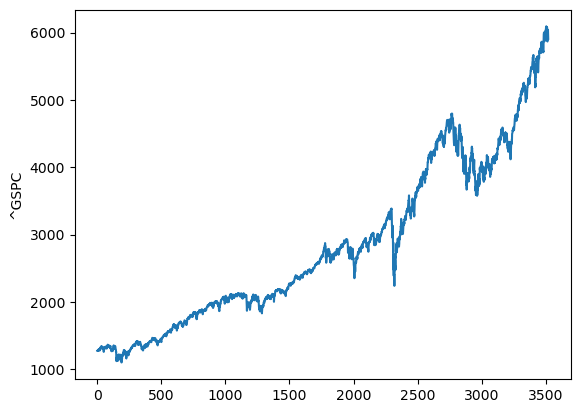

In [5]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
benchmark.head()

In [6]:
source = pd.read_pickle(source_path)
print(source.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source.head()

(3522, 439)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,WRB,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,6.112024,18.971697,71.104691,11.828708,76.192101,14.700940,43.098133,26.977388,47.841393,38.200001
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,6.072278,18.631702,69.911537,11.702991,78.568939,14.763333,43.300457,26.565216,47.206047,37.840000
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,6.045782,18.713308,70.882263,12.068158,79.582596,14.675976,43.184826,26.691620,47.240875,37.799999
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,5.977333,18.577297,71.084503,11.984348,80.162842,14.663502,43.462337,26.878460,45.778728,37.480000
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,5.939793,18.486635,70.963158,12.313586,83.001091,14.794533,43.699345,27.213682,45.770027,37.599998


### Porfolio Stats

In [7]:
def portfolio_stats(weights, data):
    logger.info("=== portfolio_stats START ===")
    logger.info(f"Input weights shape: {np.array(weights).shape}")
    logger.info(f"Input data shape: {data.shape}")
    
    weights = np.array(weights)
    logger.info("Calculating log returns...")
    returns = np.log(data) - np.log(data.shift(1)) # log return to minimize fp error
    logger.info(f"Log returns calculated, shape: {returns.shape}")
    
    # CONSISTENT: Always use log returns, never pct_change()
    logger.info("Calculating portfolio return...")
    port_return = np.sum(returns.mean() * weights) 
    logger.info(f"Portfolio return: {port_return}")
    
    logger.info("Calculating portfolio volatility...")
    port_vol = np.sqrt(np.dot(weights.T, np.dot(returns.cov() , weights)))
    logger.info(f"Portfolio volatility: {port_vol}")
    
    try:
        sharpe_ratio = port_return/port_vol
        logger.info(f"Sharpe ratio: {sharpe_ratio}")
    except Exception as e:
        logger.warning(f"Sharpe ratio calculation failed: {e}")
        sharpe_ratio = 0
    
    logger.info("=== portfolio_stats END ===")
    return sharpe_ratio, port_return, port_vol

### Fitness function

In [8]:
def fitness_function(weights, data):
    sharpe_ratio, _, _ = portfolio_stats(weights, data)
    return sharpe_ratio


In [9]:
def curried_fitness(weights, data):
    port_return = partial(fitness_function, data)
    return port_return

def minimize_sharpe(weights):
    return -1 * curried_fitness(weights)

### Data generator

Data generator to instantiate blocks on demand

In [10]:
def generate_data(df, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED):
    df2 = df.reset_index()
    benchmark2 = benchmark.reset_index()
    elements = df2.sample(n=100, random_state=seed).index # definint a maximum of 100 different sampled initial dates
    for idx in elements:
        df_sample = df2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample = df_sample.set_index('ds')
        df_sample_b = benchmark2.iloc[idx-days_to_avg:idx+days_to_opt, :]
        df_sample_b = df_sample_b.set_index('ds').drop(['index'], axis=1)
        yield df_sample, df_sample_b

### Backtest

In [11]:
def backtest(optimization_function, data, benchmark, budget, avg_period, opt_period):
    logger.info("="*80)
    logger.info("=== BACKTEST START ===")
    logger.info(f"Data shape: {data.shape}, Benchmark shape: {benchmark.shape}")
    logger.info(f"Initial capital: {budget}, Avg period: {avg_period}, Opt period: {opt_period}")
    
    portfolio_value = budget
    portfolio_returns = []
    benchmark_returns = []
    portfolio_total_return = []
    portfolio_sharpe_ratios = []
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    portfolio_value_history = pd.Series(index=data.index, name='Portfolio Value', dtype='float')
    portfolio_value_history.iloc[0] = portfolio_value

    logger.info(f"Starting backtest loop for {opt_period} iterations...")
    j = 0
    for i in range(avg_period+1, avg_period + opt_period+1):
        logger.info(f"\n--- Iteration {i-avg_period}/{opt_period} (j={j}, i={i}) ---")
        
        df = data.iloc[j:i, :]
        logger.info(f"Data slice shape: {df.shape}, Date range: {df.index[0]} to {df.index[-1]}")
        
        # Use log returns for consistency with optimization functions
        logger.info("Calculating log returns for slice...")
        df_log_returns = np.log(df) - np.log(df.shift(1))
        df_log_returns = df_log_returns.dropna(axis=0)
        logger.info(f"Log returns shape after dropna: {df_log_returns.shape}")
        
        #logger.debug(f'df_log_returns: {df_log_returns}')
        weights = optimization_function(df)
        logger.info(f"Optimization completed. Weights shape: {weights.shape}, Sum: {weights.sum():.6f}")
        logger.info(f"Weights min: {weights.min():.6f}, max: {weights.max():.6f}, non-zero count: {(weights > 0).sum()}")
        
        weights[weights < 0] = 0
        weights /= weights.sum()
        logger.info(f"Weights after normalization - Sum: {weights.sum():.6f}")
        
        weights_history.loc[df.index[-1]] = weights
        #sharpe_ratio, portfolio_return, portfolio_volatility = portfolio_stats(weights, df)
        # portfolio_change = df.iloc[-2:, :].pct_change() * weights
        logger.info("Calculating portfolio change...")
        portfolio_change = df_log_returns.iloc[-1] * weights
        #portfolio_return = portfolio_change.sum(axis=1).iloc[-1]
        portfolio_return = portfolio_change.sum()
        logger.info(f"Portfolio return for this period: {portfolio_return:.6f}")
        
        portfolio_returns.append(portfolio_return)
        # print(f'portfolio returns: {portfolio_returns}')
        # Use log returns for benchmark as well
        logger.info("Calculating benchmark returns...")
        benchmark_log_returns = np.log(benchmark.iloc[j:i, :]) - np.log(benchmark.iloc[j:i, :].shift(1))
        benchmark_return = benchmark_log_returns.iloc[-1].values.tolist()[0]
        logger.info(f"Benchmark return for this period: {benchmark_return:.6f}")
        
        benchmark_returns.append(benchmark_return)
        # print(f'benchmark_returns: {benchmark_returns}')
        logger.info("Calculating cumulative returns...")
        portfolio_cumulative_returns = np.cumprod([k + 1 for k in portfolio_returns])
        # print(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
        benchmark_cumulative_returns = np.cumprod([k + 1 for k in  benchmark_returns])
        # print(f'benchmark cumulative returns: {benchmark_cumulative_returns}')
        portfolio_mean_return = np.mean(portfolio_returns)
        benchmark_mean_return = np.mean(benchmark_returns)
        portfolio_volatility = np.std(portfolio_returns) 
        benchmark_volatility = np.std(benchmark_returns)
        logger.info(f"Portfolio mean return: {portfolio_mean_return:.6f}, volatility: {portfolio_volatility:.6f}")
        logger.info(f"Benchmark mean return: {benchmark_mean_return:.6f}, volatility: {benchmark_volatility:.6f}")
        
        try:
            sharpe_ratio = (portfolio_mean_return) / portfolio_volatility
            logger.info(f"Sharpe ratio: {sharpe_ratio:.6f}")
        except Exception as e:
            logger.warning(f"Sharpe ratio calculation failed: {e}")
            sharpe_ratio = 0
        portfolio_sharpe_ratios.append(sharpe_ratio)

         # Portfolio & Benchmark value
        benchmark_value = budget * benchmark_cumulative_returns[-1]
        portfolio_value = budget * portfolio_cumulative_returns[-1]
        logger.info(f"Portfolio value: ${portfolio_value:,.2f}, Benchmark value: ${benchmark_value:,.2f}")
        j += 1

    logger.info("\nCalculating final cumulative returns...")
    portfolio_cumulative_returns = portfolio_cumulative_returns - portfolio_cumulative_returns[0]
    benchmark_cumulative_returns = benchmark_cumulative_returns - benchmark_cumulative_returns[0]
    logger.info(f"Final portfolio cumulative return: {portfolio_cumulative_returns[-1]:.6f}")
    logger.info(f"Final benchmark cumulative return: {benchmark_cumulative_returns[-1]:.6f}")

    # Plot the results
    logger.info("Creating plot...")
    plt.figure(figsize=(12, 6))
    plt.plot(portfolio_cumulative_returns, label='Portfolio')
    plt.plot(benchmark_cumulative_returns, label='Benchmark')
    #plt.plot(portfolio_returns, label='Portfolio')
    #plt.plot(benchmark_returns, label='Benchmark')
    plt.legend(loc='upper left')
    plt.title('Backtesting Results')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Returns')
    plt.show()

    logger.info("=== BACKTEST END ===")
    logger.info("="*80)
    return weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns

In [12]:
import pickle

def write_pickle_dict(data, file_path):
    """Pickles a dictionary and saves it to a file."""
    try:
        with open(file_path, 'wb') as f:  # Open the file in binary write mode ('wb')
            pickle.dump(data, f)
        print(f"Dictionary pickled and saved to {file_path}")
    except Exception as e:
        print(f"An error occurred while pickling: {e}")

def read_pickle_dict(file_path):
    try:
        with open(file_path, 'rb') as f:
            loaded_dict = pickle.load(f)
    except FileNotFoundError:
        print(f"Error: File '{file_path}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")
    return loaded_dict

### Run Experiment Function

In [13]:
def run_experiment(results_path_template, data, benchmark, opt_fun, parameters):
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT START ###")
    logger.info("#"*100)
    logger.info(f"Results path template: {results_path_template}")
    logger.info(f"Data shape: {data.shape}")
    logger.info(f"Benchmark shape: {benchmark.shape}")
    logger.info(f"Parameters: {parameters}")

    n_periods = parameters['n_periods']
    days_to_avg = parameters['days_to_avg']
    days_to_opt = parameters['days_to_opt']
    population_size = parameters['population_size']
    num_generations = parameters['num_generations']
    budget = parameters['budget']
    
    logger.info(f"Creating data generator with n_periods={n_periods}...")
    datagen = generate_data(data, benchmark)

        
    for i in range(n_periods):
        logger.info(f"\n{'='*80}")
        logger.info(f"PERIOD {i+1}/{n_periods}")
        logger.info(f"{'='*80}")
        
        results_path = results_path_template.format(i)
        logger.info(f"Results path: {results_path}")
        
        if not os.path.exists(results_path):
            logger.info(f"Results file does not exist, running optimization...")
            try:
                logger.info("Getting next data sample from generator...")
                df, df_b = next(datagen)
                logger.info(f"Data sample retrieved - df shape: {df.shape}, benchmark shape: {df_b.shape}")
                print(f'initial date: {df.iloc[days_to_avg+1:, :].index[0]}')
                
                logger.info("Creating source data plot...")
                plt.figure(figsize=(12, 6))
                plt.plot(df.iloc[days_to_avg+1:days_to_avg+days_to_opt+1, :].sum(axis=1), label='Source')
                plt.plot(df_b, label='Benchmark')
                plt.legend(loc='upper left')
                plt.title('Source Data')
                plt.xlabel('Date')
                plt.ylabel('Stock Values')
                plt.show()
                
                logger.info(f"Starting backtest at {datetime.now()}")
                start_time = datetime.now()
                
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = backtest(opt_fun, df, df_b, budget=budget, avg_period=days_to_avg,opt_period=days_to_opt)
                
                end_time = datetime.now()
                dt = abs(end_time - start_time)
                logger.info(f'Backtest completed at {end_time}')
                logger.info(f'Total backtest time: {dt.total_seconds():.2f} seconds')
                logger.debug(f'portfolio cumulative returns: {portfolio_cumulative_returns}')
                
            except Exception as e: 
                logger.error(f'FAILED {results_path} due to {e}', exc_info=True)
                print(f'Failed {results_path} due to {e}')
                weights_history, portfolio_value_history, portfolio_cumulative_returns, benchmark_cumulative_returns = [], [], [], []
                dt = timedelta(0)

            logger.info("Saving results to pickle file...")
            result = {
                "round": i, 
                "start_date": df.index[0],
                "end_date": df.index[-1],
                "population_size": population_size,
                "num_generations": num_generations,
                "days_to_avg": days_to_avg,
                "days_to_opt": days_to_opt,
                "weights_history": weights_history,
                "portfolio_value_history": portfolio_value_history,
                "portfolio_cumulative_returns": portfolio_cumulative_returns,
                "benchmark_cumulative_returns": benchmark_cumulative_returns,
                "total_run_time": dt.total_seconds()
                }
            write_pickle_dict(result, results_path)
            logger.info(f"Results saved successfully to {results_path}")

        else:
            logger.info(f"Results file already exists, loading from {results_path}...")
            results = read_pickle_dict(results_path)
            portfolio_cumulative_returns = results['portfolio_cumulative_returns']
            benchmark_cumulative_returns = results['benchmark_cumulative_returns']
            weights_history = results.get('weights_history', None)
            logger.info(f"Results loaded - portfolio return: {portfolio_cumulative_returns[-1] if len(portfolio_cumulative_returns) > 0 else 'N/A'}")

        # Plot final weight histogram at the end of each period (for both new and loaded data)
        if weights_history is not None and isinstance(weights_history, pd.DataFrame) and not weights_history.empty:
            logger.info("Plotting final weight distribution for this period...")
            # Get the last row (final weights)
            final_weights_row = weights_history.dropna(how='all').iloc[-1]
            final_date = weights_history.dropna(how='all').index[-1]
            
            weights = final_weights_row.values
            # Convert to numeric and filter out NaN values
            weights = pd.to_numeric(weights, errors='coerce')
            weights = weights[~np.isnan(weights)]
            
            if len(weights) > 0:
                print(f"\nPeriod {i+1} Final Weights - Weight Statistics:")
                print(f"  Min weight:     {weights.min():.6f}")
                print(f"  Max weight:     {weights.max():.6f}")
                print(f"  Average weight: {weights.mean():.6f}")
                print(f"  Non-zero count: {(weights > 0).sum()}/{len(weights)}")
                
                # Plot histogram of final weight distribution
                plt.figure(figsize=(10, 4))
                plt.hist(weights[weights > 0], bins=50, edgecolor='black', alpha=0.7)
                plt.xlabel('Weight')
                plt.ylabel('Frequency')
                plt.title(f'Final Weight Distribution - Period {i+1} (Date: {final_date})')
                plt.grid(True, alpha=0.3)
                plt.show()

        # Plot the cumulative returns
        logger.info("Creating results plot...")
        plt.figure(figsize=(12, 6))
        plt.plot(portfolio_cumulative_returns, label='Portfolio')
        plt.plot(benchmark_cumulative_returns, label='Benchmark')
        plt.legend(loc='upper left')
        plt.title('Backtesting Results')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Returns')
        plt.show()
    
    logger.info("\n" + "#"*100)
    logger.info("### RUN EXPERIMENT END ###")
    logger.info("#"*100 + "\n")
    return None

### Comparison functions

In [14]:
def multi_comparison(solver_configs, n_periods, title_prefix="Portfolio Optimization", show_benchmark=True):
    """
    Compare multiple portfolio optimization solvers across periods.
    
    Args:
        solver_configs (list): List of dictionaries with 'path_template' and 'name' keys
        n_periods (int): Number of periods to compare
        title_prefix (str): Prefix for plot titles
        show_benchmark (bool): Whether to show benchmark comparison
    """
    
    for period in range(n_periods):
        period_data = []
        benchmark_data = None
        
        # Load data for all solvers for this period
        for config in solver_configs:
            path_template = config['path_template']
            solver_name = config['name']
            file_path = path_template.format(period)
            
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    benchmark_returns = result_data.get('benchmark_cumulative_returns', [])
                    start_date = result_data.get('start_date', 'Unknown')
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Check if portfolio_returns has data (handle NumPy arrays properly)
                    has_portfolio_data = False
                    if portfolio_returns is not None:
                        try:
                            has_portfolio_data = len(portfolio_returns) > 0
                        except TypeError:
                            # Handle case where portfolio_returns is not a sequence
                            has_portfolio_data = portfolio_returns is not None
                    
                    if has_portfolio_data:
                        period_data.append({
                            'name': solver_name,
                            'portfolio_returns': portfolio_returns,
                            'benchmark_returns': benchmark_returns,
                            'start_date': start_date,
                            'execution_time': execution_time,
                            'file_path': file_path
                        })
                        
                        # Store benchmark from first successful load
                        if benchmark_data is None and benchmark_returns is not None:
                            try:
                                if len(benchmark_returns) > 0:
                                    benchmark_data = benchmark_returns
                            except (TypeError, AttributeError):
                                pass
                        
                        logger.info(f'Period {period}: Loaded {solver_name} (exec_time: {execution_time:.2f}s)')
                    else:
                        logger.warning(f'Period {period}: {solver_name} has no portfolio returns data')
                else:
                    logger.warning(f'Period {period}: Could not load {solver_name} from {file_path}')
                    
            except Exception as e:
                logger.error(f'Period {period}: Error loading {solver_name} from {file_path}: {e}')
        
        # Plot results if we have any data
        if period_data:
            plt.figure(figsize=(15, 8))
            
            # Color palette for better distinction
            colors = plt.cm.Set1(np.linspace(0, 1, len(period_data)))
            
            # Plot portfolio returns for each solver
            for i, data in enumerate(period_data):
                plt.plot(data['portfolio_returns'], 
                        label=f"{data['name']} (t={data['execution_time']:.1f}s)", 
                        color=colors[i], 
                        linewidth=2, 
                        alpha=0.8)
            
            # Plot benchmark if available and requested
            if show_benchmark and benchmark_data is not None:
                plt.plot(benchmark_data, 
                        label='S&P 500 Benchmark', 
                        linestyle='--', 
                        color='black', 
                        linewidth=2, 
                        alpha=0.7)
            
            plt.title(f'{title_prefix} Comparison - Period {period}\\n'
                     f'Start Date: {period_data[0]["start_date"]} | Solvers: {len(period_data)}')
            plt.xlabel('Trading Days')
            plt.ylabel('Cumulative Returns')
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            # Print summary statistics
            print(f"\\nPeriod {period} Summary:")
            print("-" * 50)
            for data in period_data:
                try:
                    final_return = data['portfolio_returns'][-1] if len(data['portfolio_returns']) > 0 else 0
                except (IndexError, TypeError):
                    final_return = 0
                print(f"{data['name']:<25}: {final_return:>8.4f} ({data['execution_time']:>6.2f}s)")
            if benchmark_data is not None:
                try:
                    benchmark_final = benchmark_data[-1] if len(benchmark_data) > 0 else 0
                except (IndexError, TypeError):
                    benchmark_final = 0
                print(f"{'Benchmark':<25}: {benchmark_final:>8.4f}")
            print()
            
        else:
            logger.warning(f'No data available for any solver in period {period}')

def performance_summary(solver_configs, n_periods):
    """Generate performance summary across all periods for multiple solvers."""
    summary_data = []
    
    for config in solver_configs:
        solver_name = config['name']
        path_template = config['path_template']
        
        returns_data = []
        execution_times = []
        successful_periods = 0
        
        for period in range(n_periods):
            file_path = path_template.format(period)
            try:
                result_data = read_pickle_dict(file_path)
                if result_data is not None:
                    portfolio_returns = result_data.get('portfolio_cumulative_returns', [])
                    execution_time = result_data.get('total_run_time', 0)
                    
                    # Safe check for portfolio returns data
                    try:
                        if portfolio_returns is not None and len(portfolio_returns) > 0:
                            final_return = portfolio_returns[-1]
                            returns_data.append(final_return)
                            execution_times.append(execution_time)
                            successful_periods += 1
                    except (TypeError, IndexError):
                        pass
            except Exception as e:
                logger.debug(f'Could not process {file_path}: {e}')
        
        if returns_data:
            summary_data.append({
                'Solver': solver_name,
                'Periods': successful_periods,
                'Avg_Return': np.mean(returns_data),
                'Std_Return': np.std(returns_data),
                'Min_Return': np.min(returns_data),
                'Max_Return': np.max(returns_data),
                'Avg_Time': np.mean(execution_times),
                'Std_Time': np.std(execution_times),
                'Success_Rate': successful_periods / n_periods * 100
            })
    
    if summary_data:
        df = pd.DataFrame(summary_data)
        df = df.round(4)
        return df
    else:
        return pd.DataFrame()


### Analysis of total amount

<Axes: xlabel='ds'>

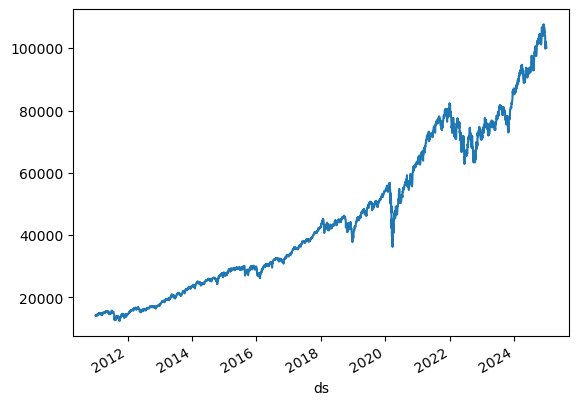

In [15]:
source.sum(axis=1).plot()

total sum if we consider a portfolio with one share per ticker then we get around $100,000 by 2024. We need to set budget to a higher value, 1,000,000 in this case.

In [16]:
parameters = {
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "budget": 1_000_000,
}

### Experiment 1: Wide dataStocks + ETFs

In [17]:
source_path_extended = '../../data/etfs_close.pkl'

In [18]:
source_extended = pd.read_pickle(source_path_extended)
source_extended.head()

Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [19]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(source_wide.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_wide.isnull().values.any()
print("Any NaN in source_wide:", has_any_nan)
source_wide.head()

(3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [20]:
df = source_wide.copy()
days_to_avg = parameters['days_to_avg']
display(df.head())
print(f'initial date: {df.iloc[days_to_avg+1, :].index}')

Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


initial date: Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'XLP', 'XLU', 'XLV', 'XLY', 'XME', 'XOP', 'XPH', 'XRT', 'XSD', 'XTNT'],
      dtype='object', name='Ticker', length=680)


<Axes: xlabel='ds'>

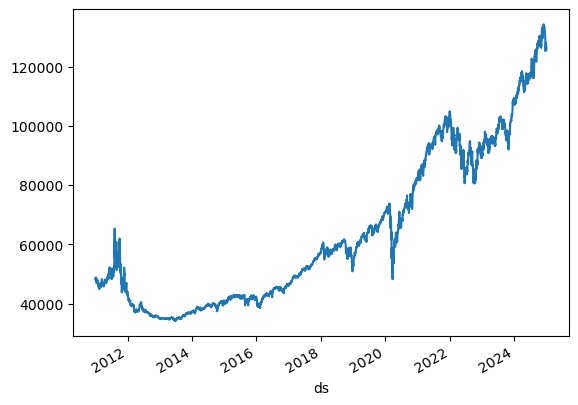

In [21]:
df.sum(axis=1).plot()

#### Equal Weights Baseline

In [22]:
opt_fun_ew = partial(equal_weights_baseline)


Period 1 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


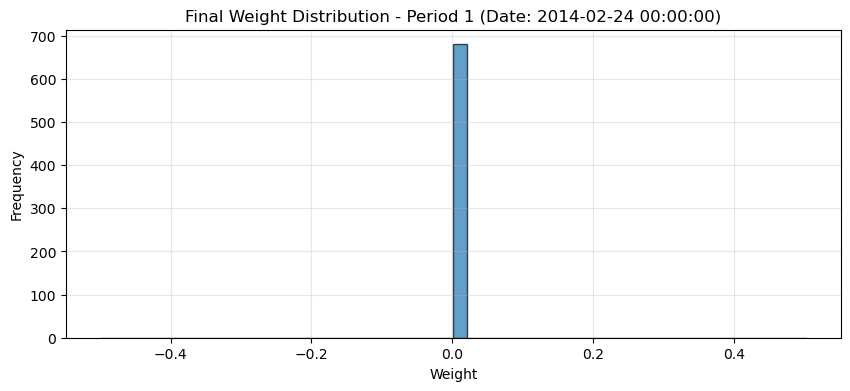

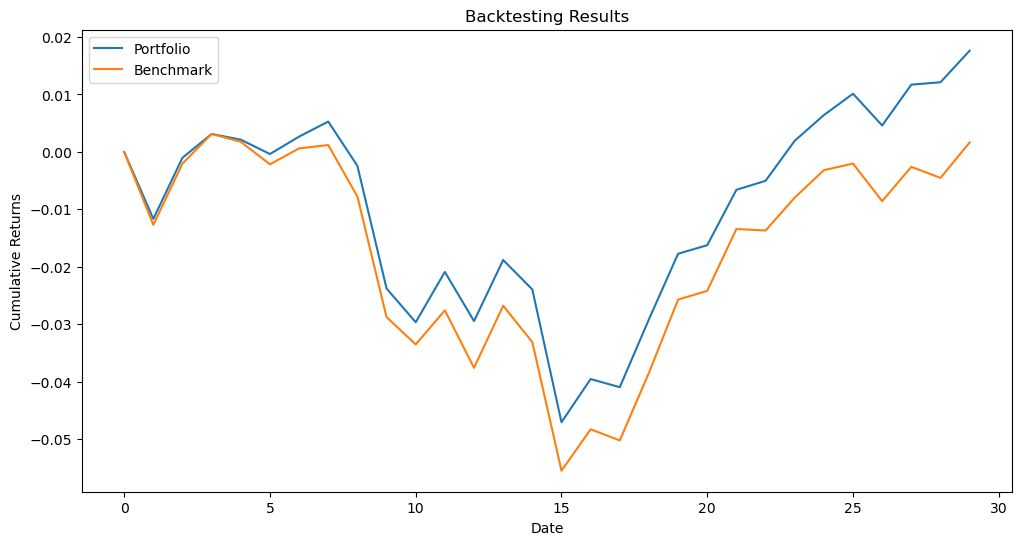


Period 2 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


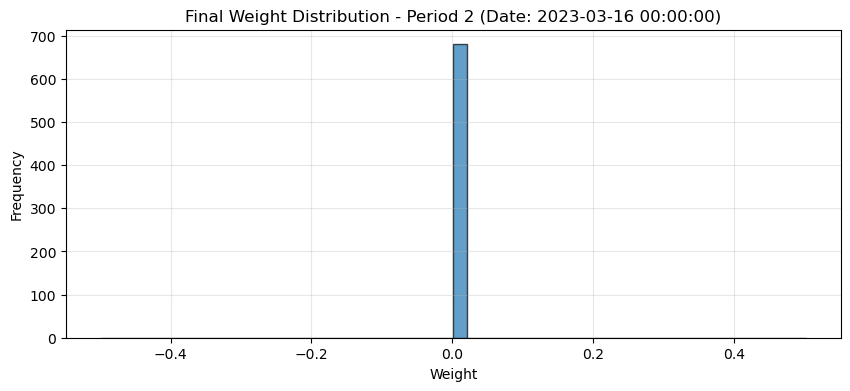

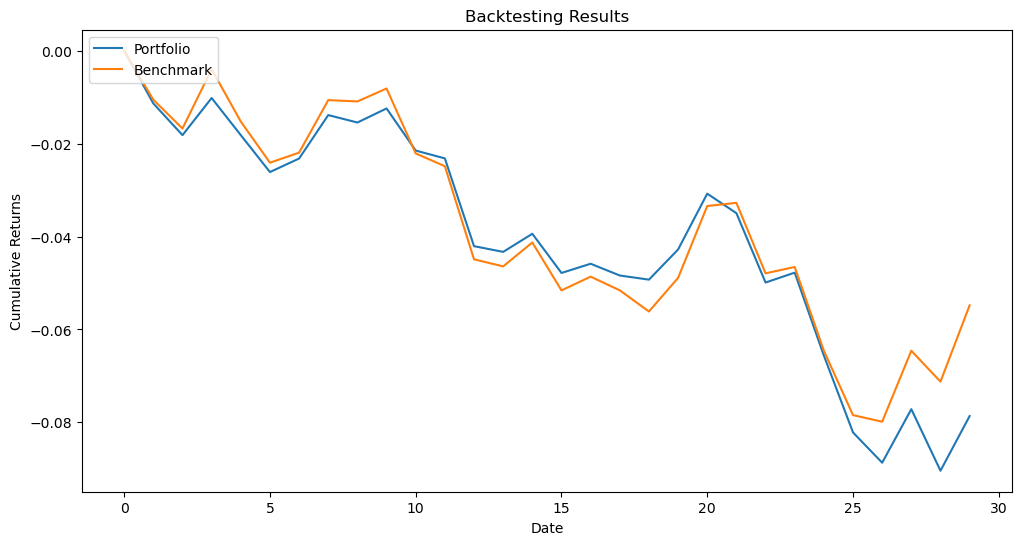


Period 3 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


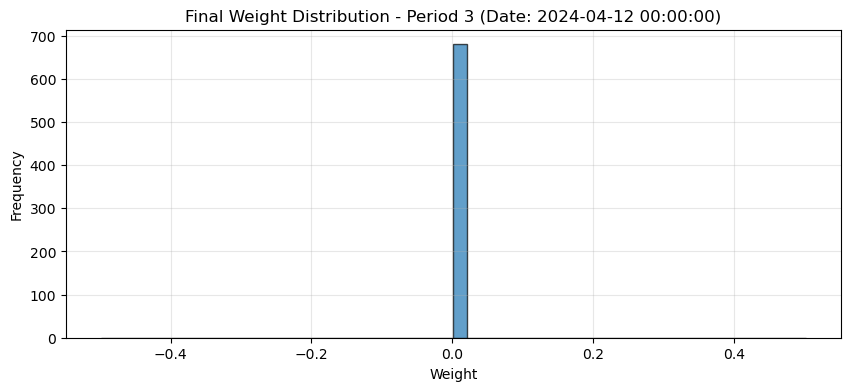

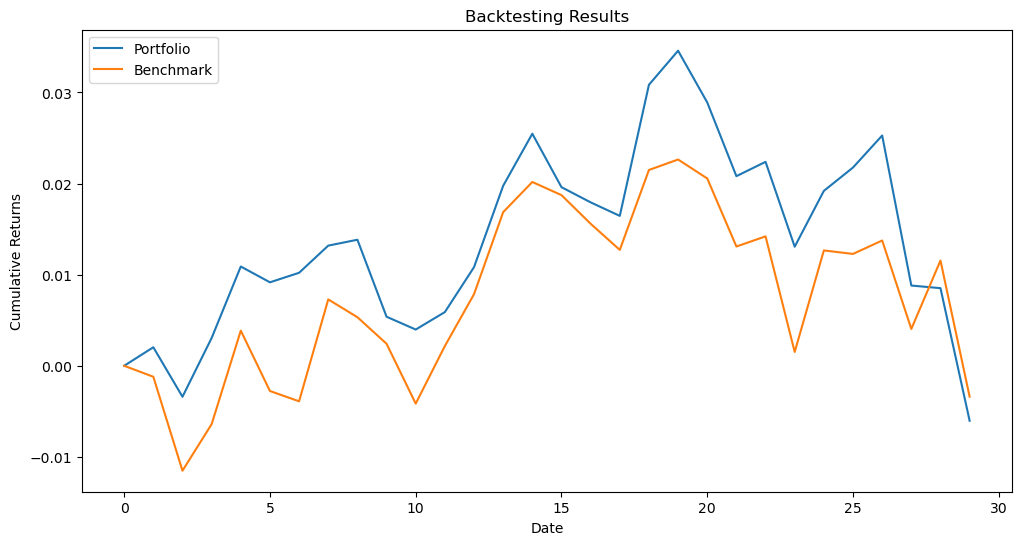


Period 4 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


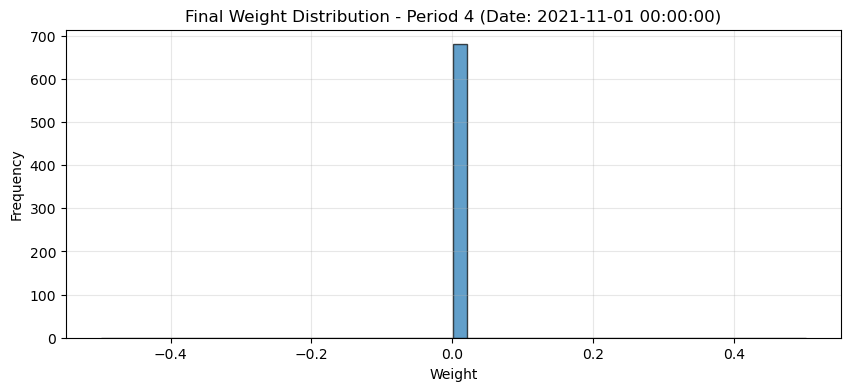

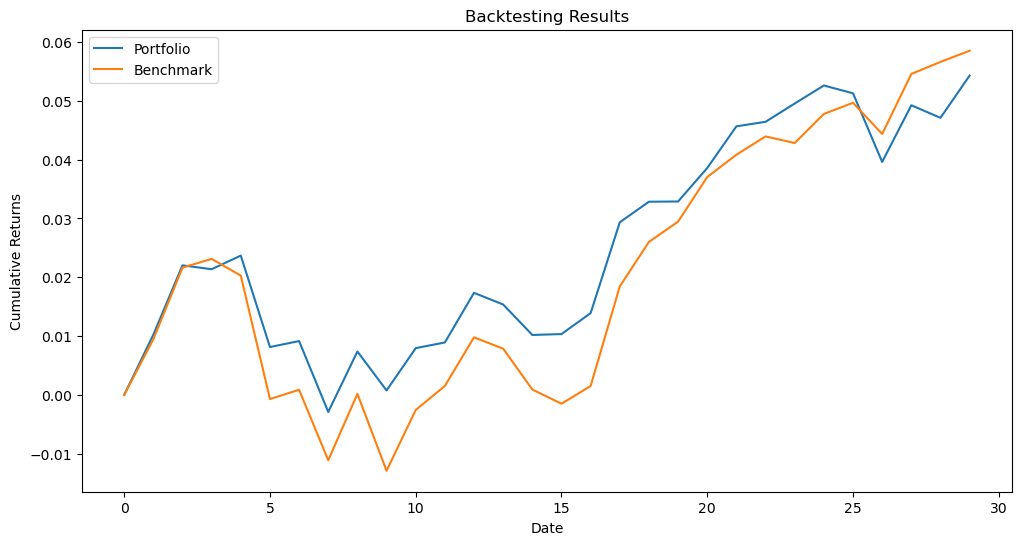


Period 5 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


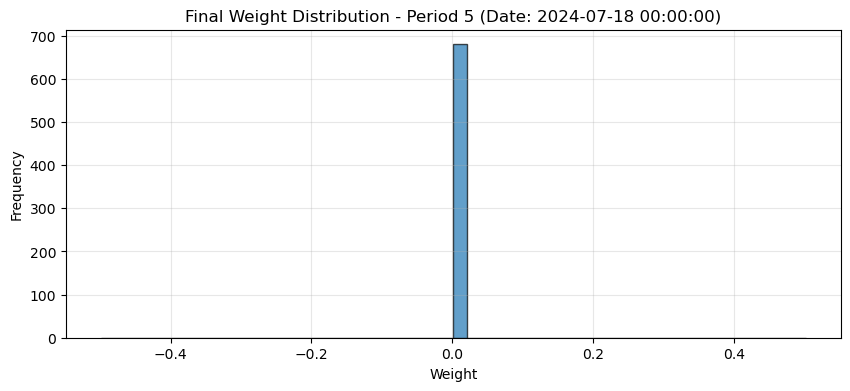

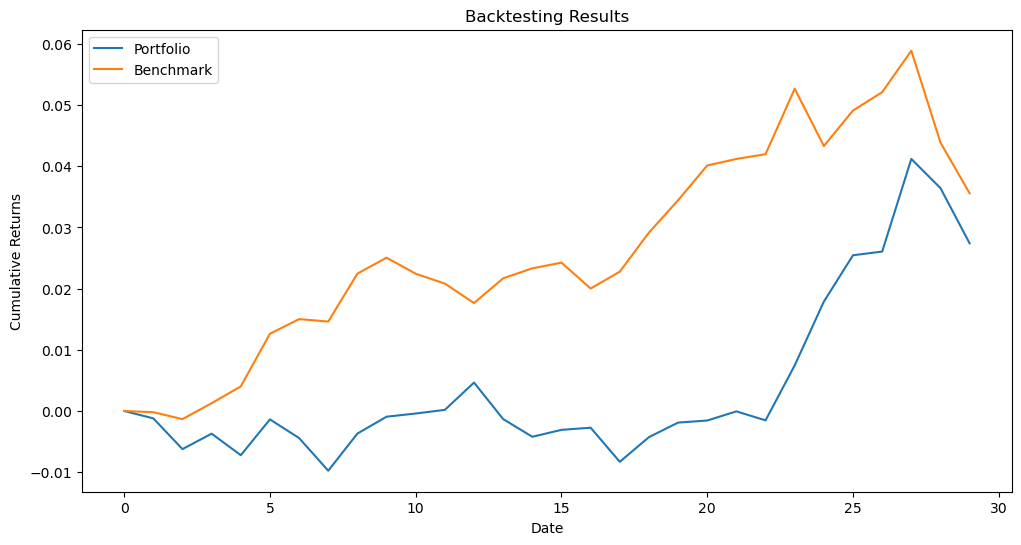


Period 6 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


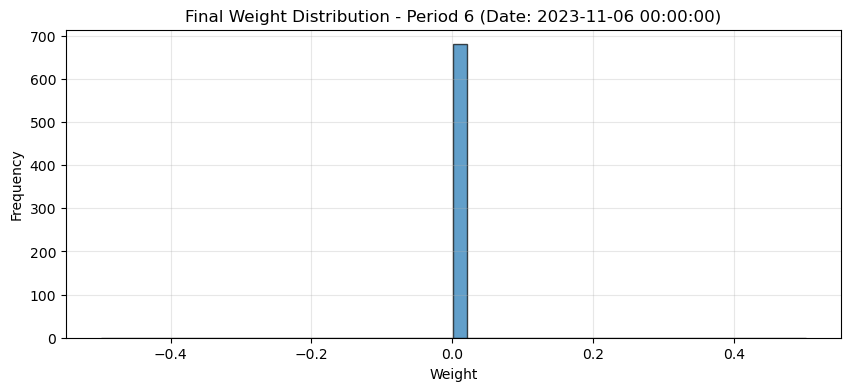

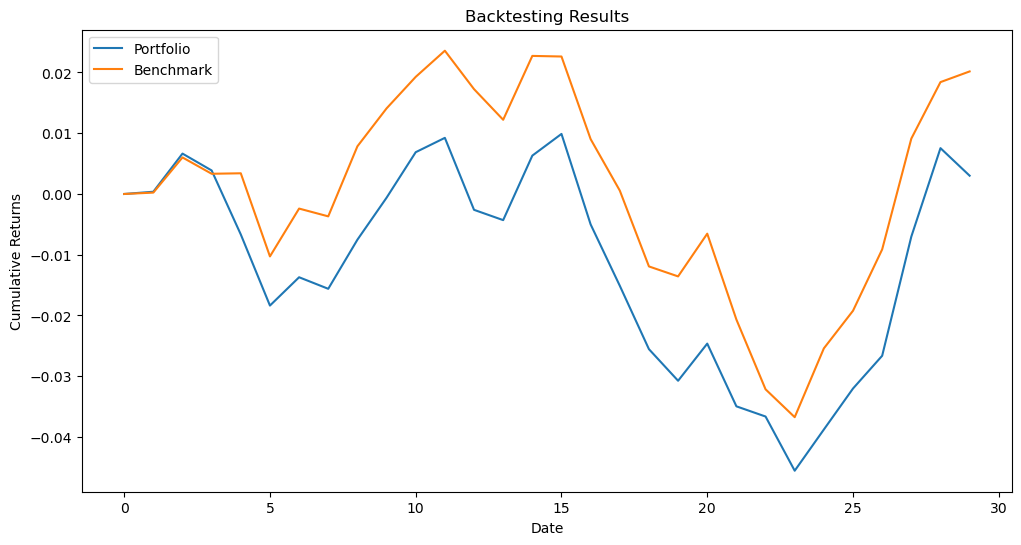


Period 7 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


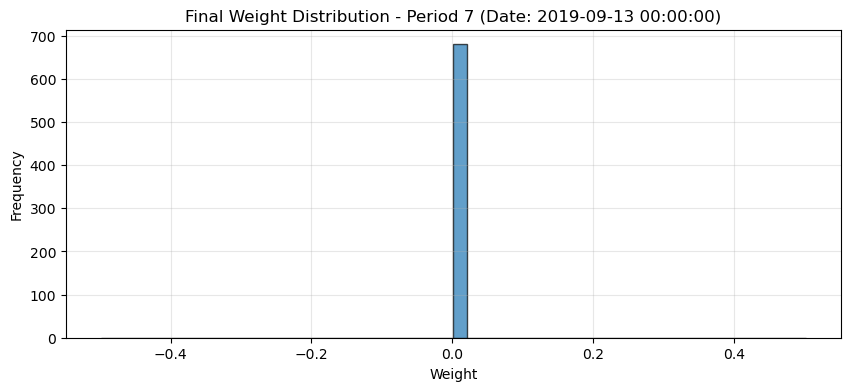

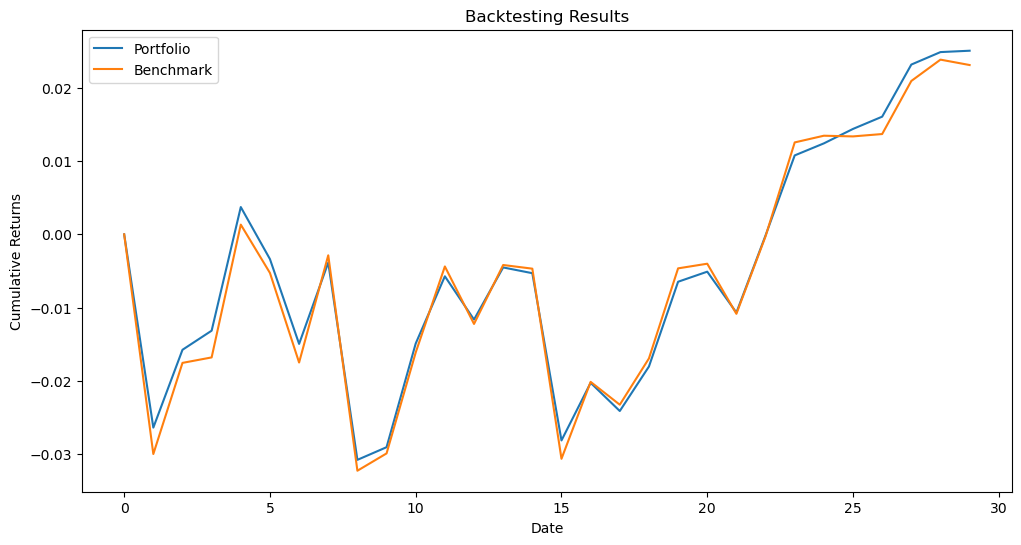


Period 8 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


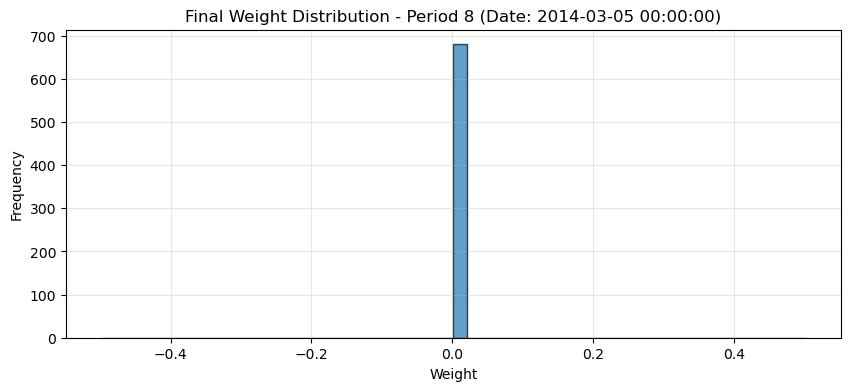

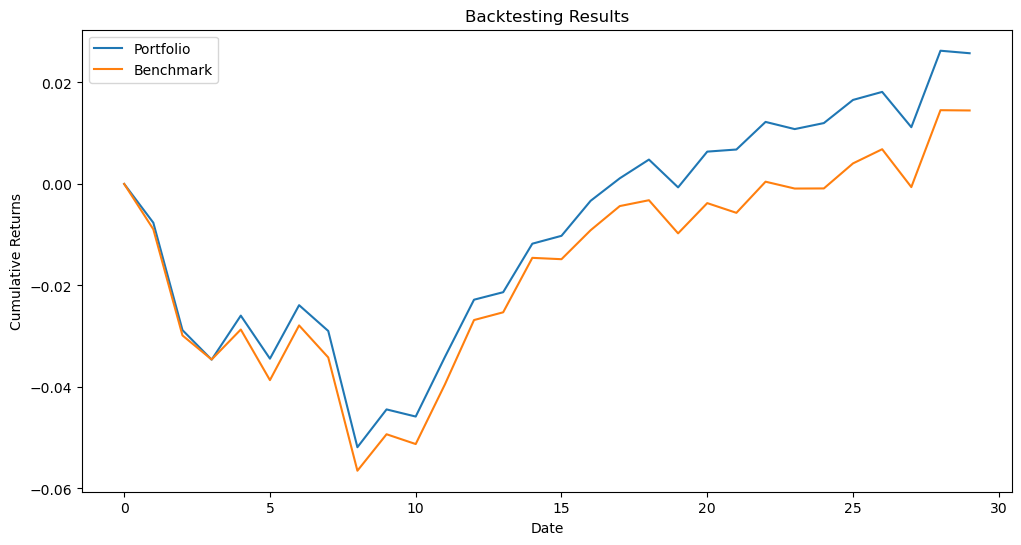


Period 9 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


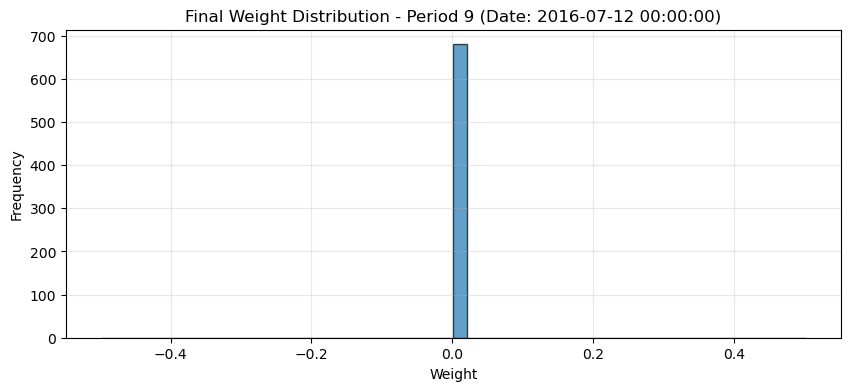

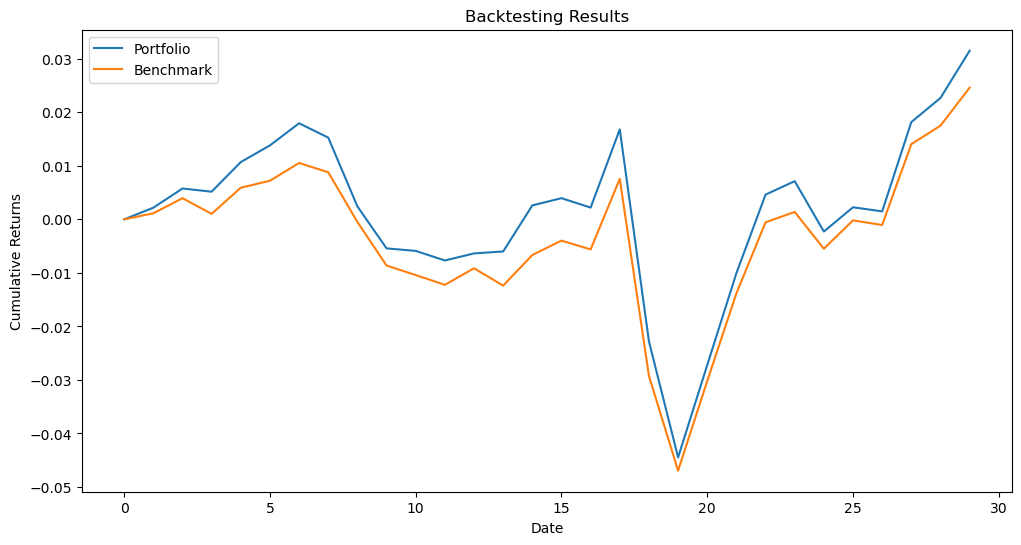


Period 10 Final Weights - Weight Statistics:
  Min weight:     0.001471
  Max weight:     0.001471
  Average weight: 0.001471
  Non-zero count: 680/680


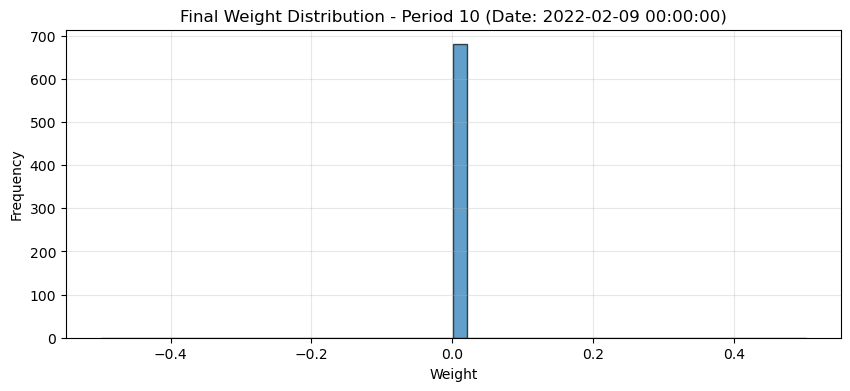

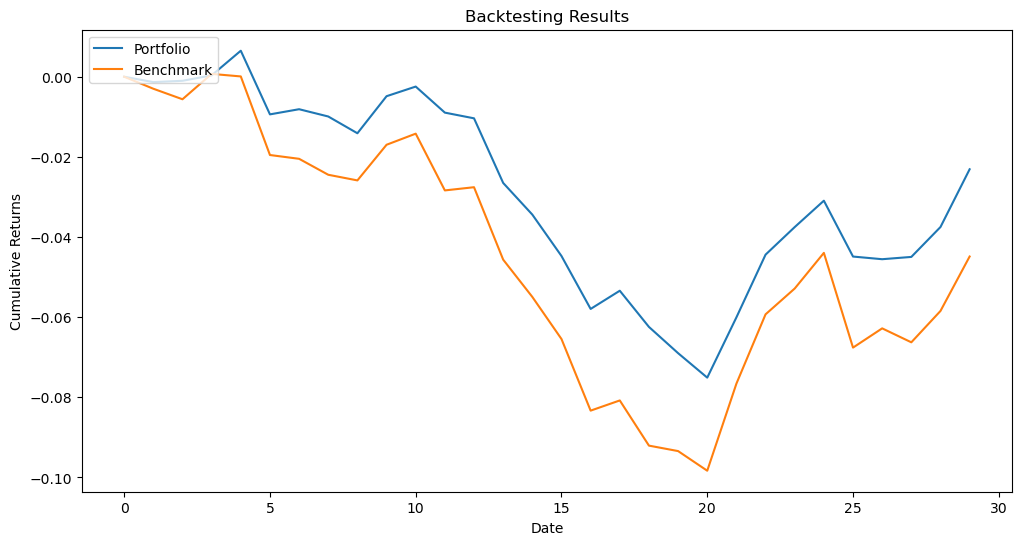

In [23]:
results_path_ew_wide = '../../results/qubo/results_ew_{}.pkl'
_ = run_experiment(results_path_ew_wide, df, benchmark, opt_fun_ew, parameters)

### GA

In [24]:
opt_fun_ga = partial(genetic_algorithm_qubo, 
                  population_size=parameters["population_size"], 
                  num_generations=parameters["num_generations"], 
                  mutation_rate=parameters["mutation_rate"], 
                  elitism=parameters["elitism"])


Period 1 Final Weights - Weight Statistics:
  Min weight:     0.001001
  Max weight:     0.004805
  Average weight: 0.001471
  Non-zero count: 680/680


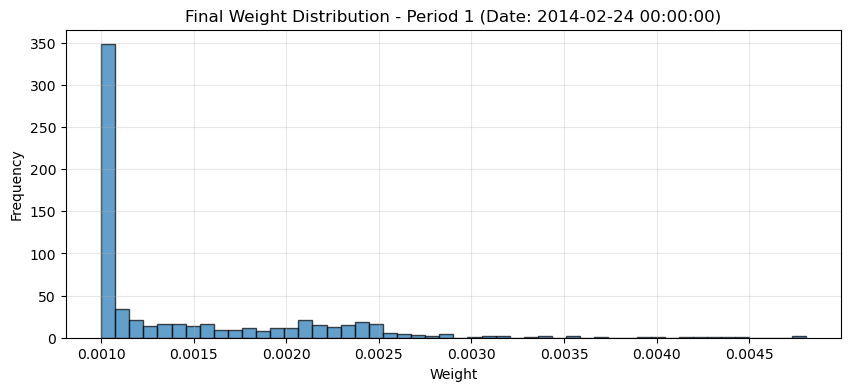

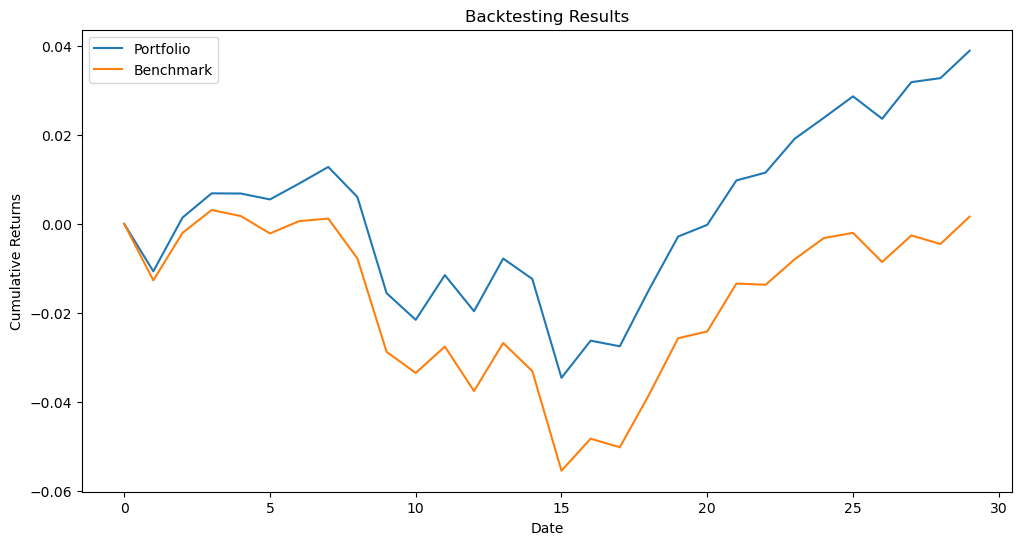


Period 2 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.004568
  Average weight: 0.001471
  Non-zero count: 680/680


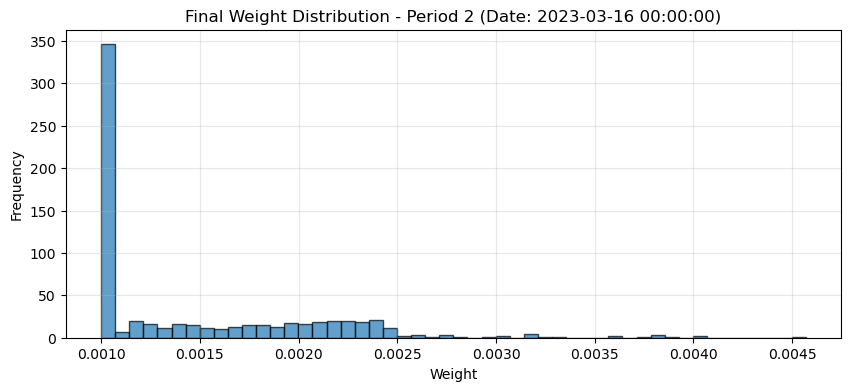

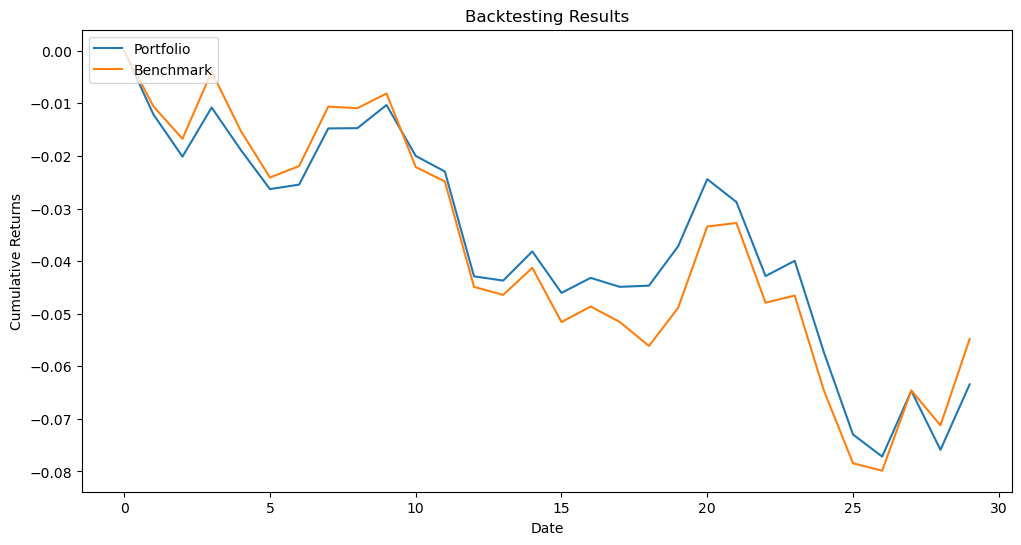


Period 3 Final Weights - Weight Statistics:
  Min weight:     0.001004
  Max weight:     0.005122
  Average weight: 0.001471
  Non-zero count: 680/680


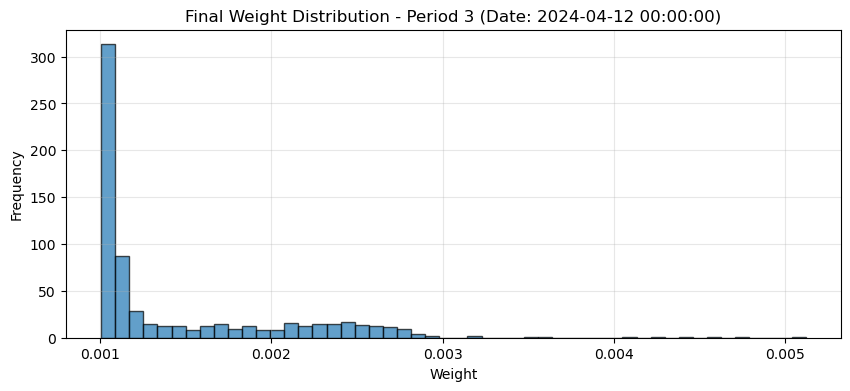

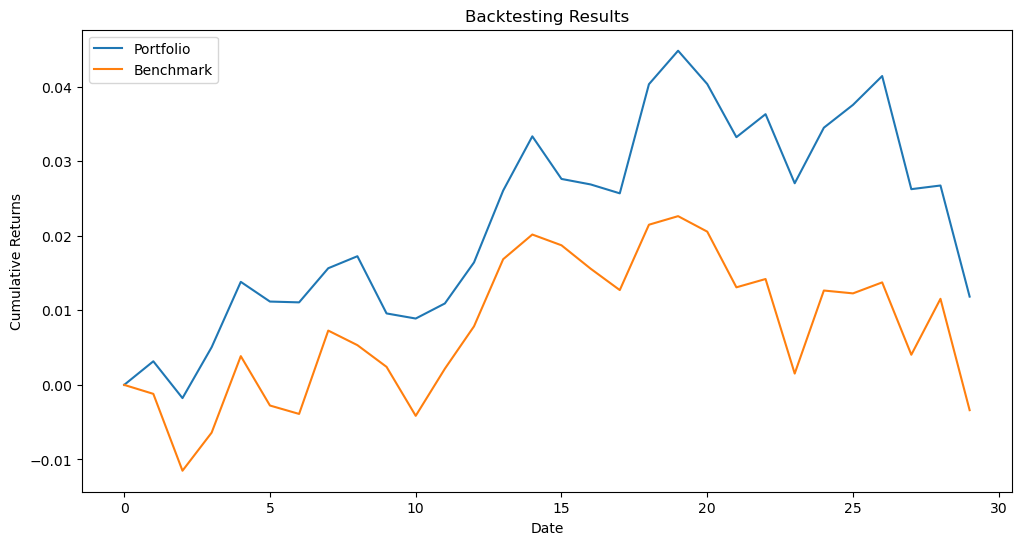


Period 4 Final Weights - Weight Statistics:
  Min weight:     0.001001
  Max weight:     0.004116
  Average weight: 0.001471
  Non-zero count: 680/680


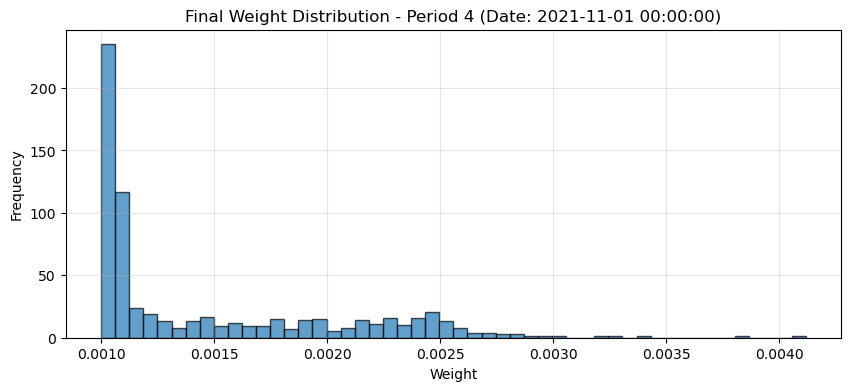

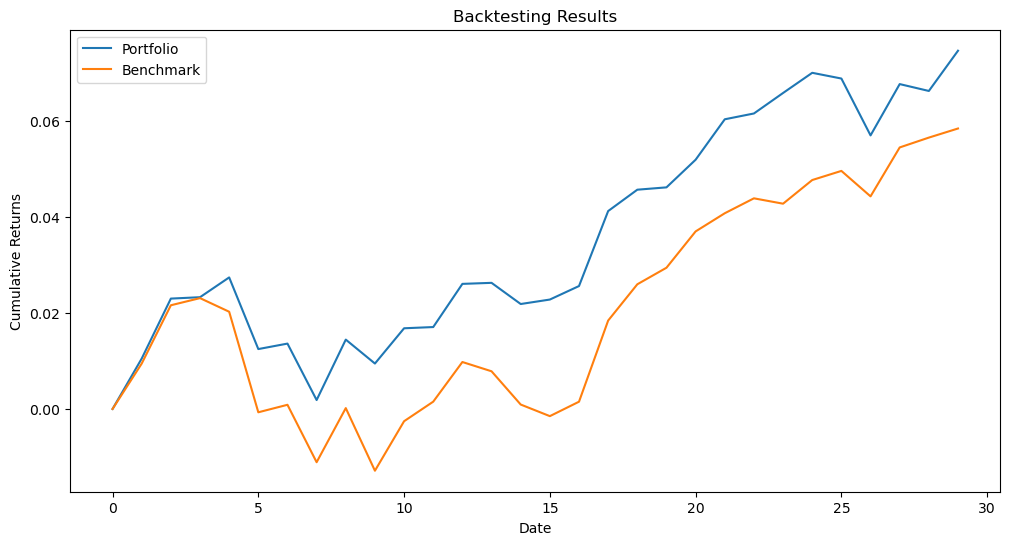


Period 5 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.005454
  Average weight: 0.001471
  Non-zero count: 680/680


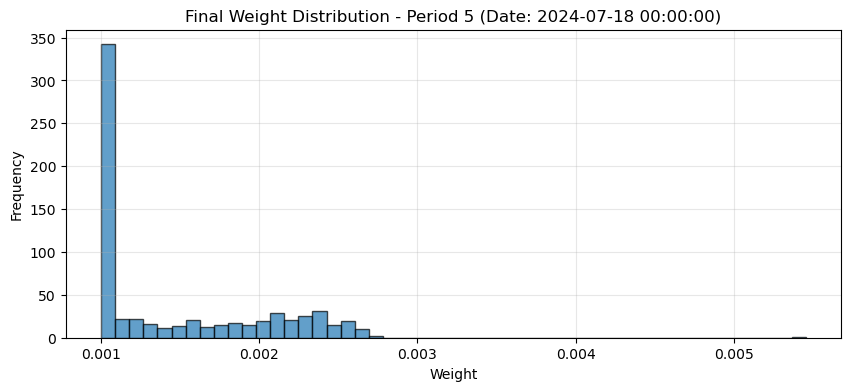

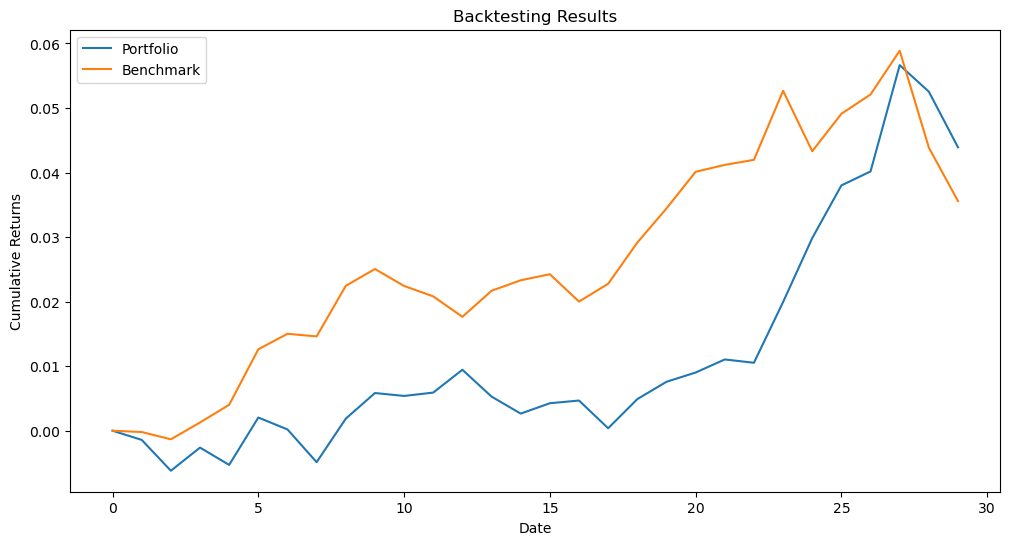


Period 6 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.005630
  Average weight: 0.001471
  Non-zero count: 680/680


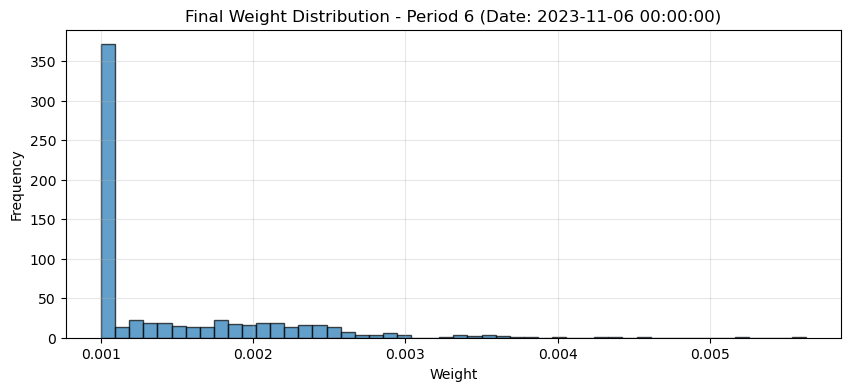

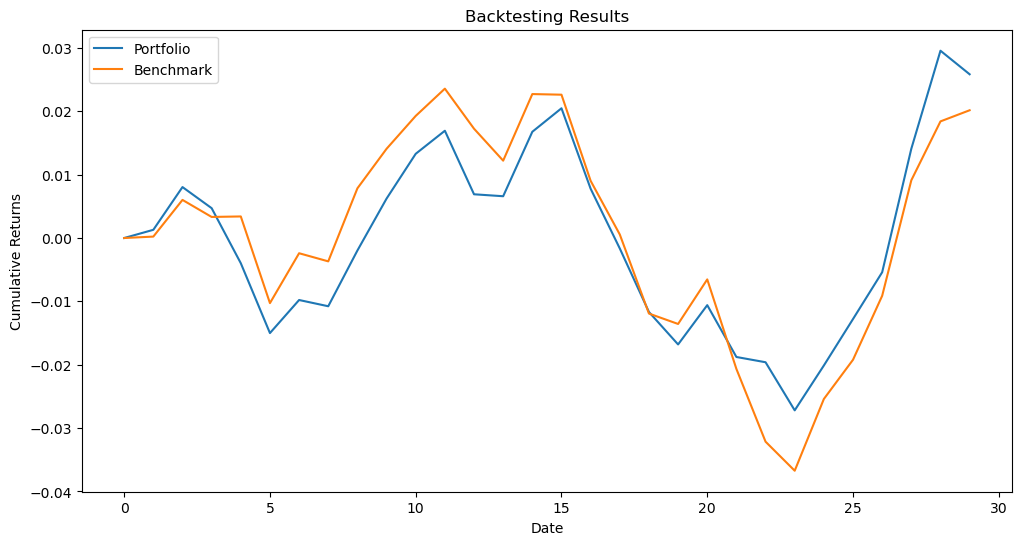


Period 7 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.004841
  Average weight: 0.001471
  Non-zero count: 680/680


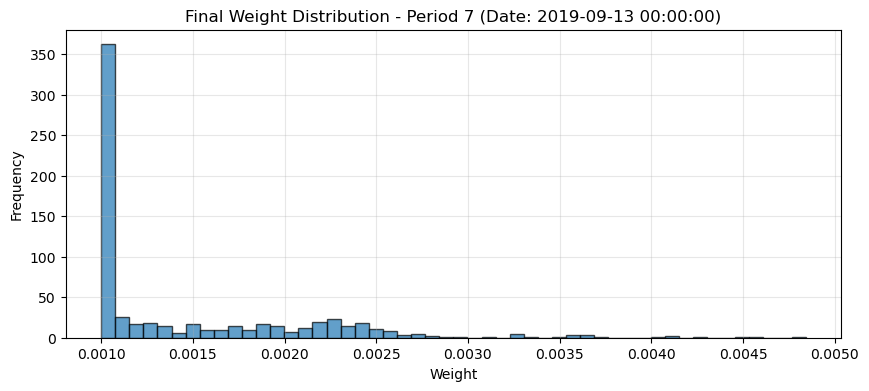

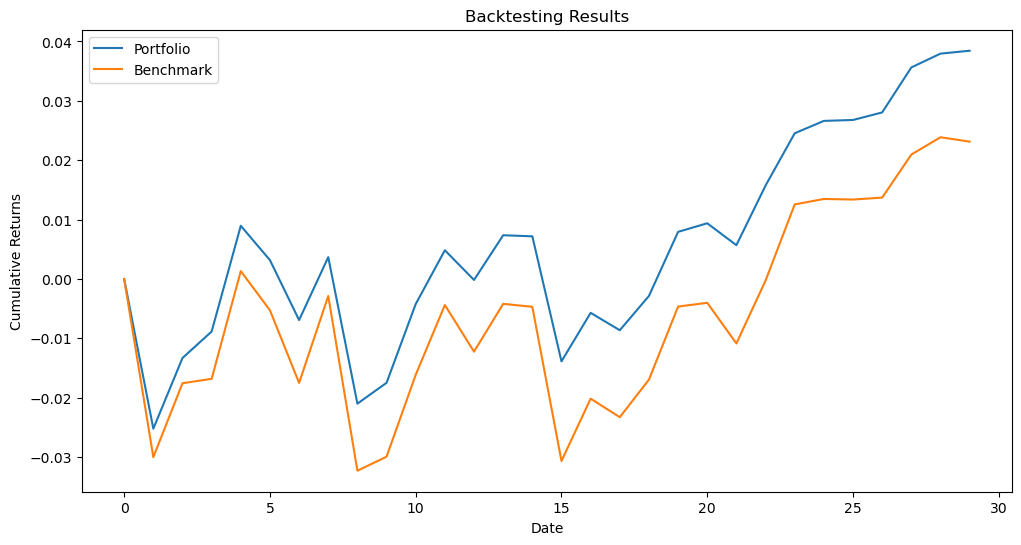


Period 8 Final Weights - Weight Statistics:
  Min weight:     0.001001
  Max weight:     0.004117
  Average weight: 0.001471
  Non-zero count: 680/680


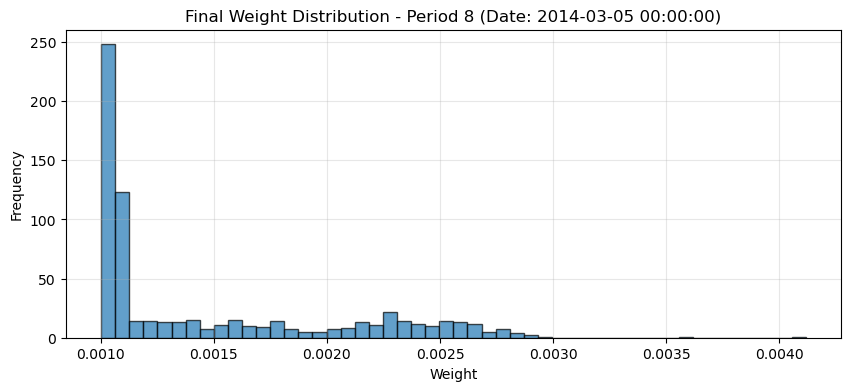

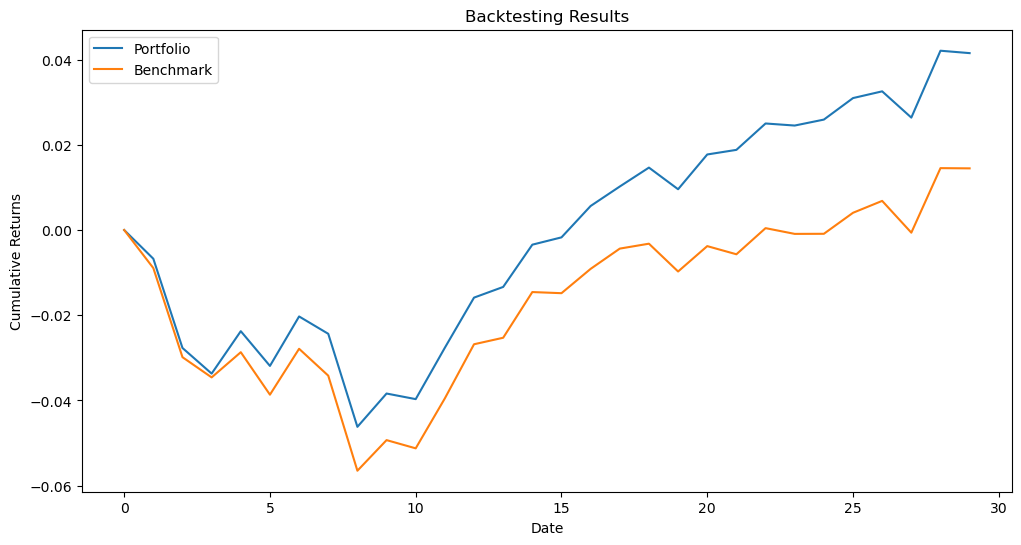


Period 9 Final Weights - Weight Statistics:
  Min weight:     0.001001
  Max weight:     0.004936
  Average weight: 0.001471
  Non-zero count: 680/680


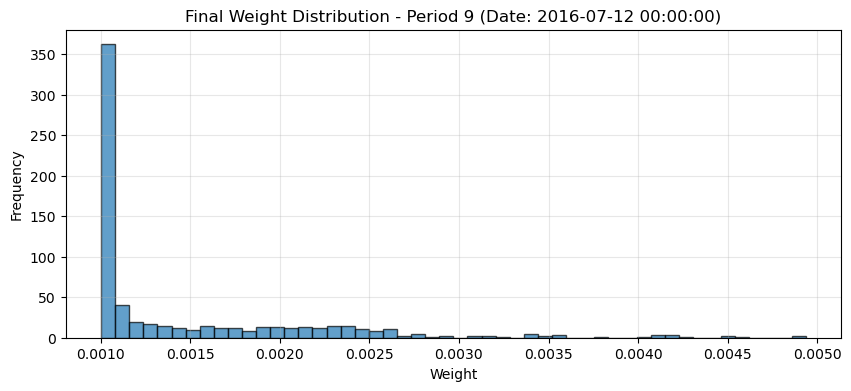

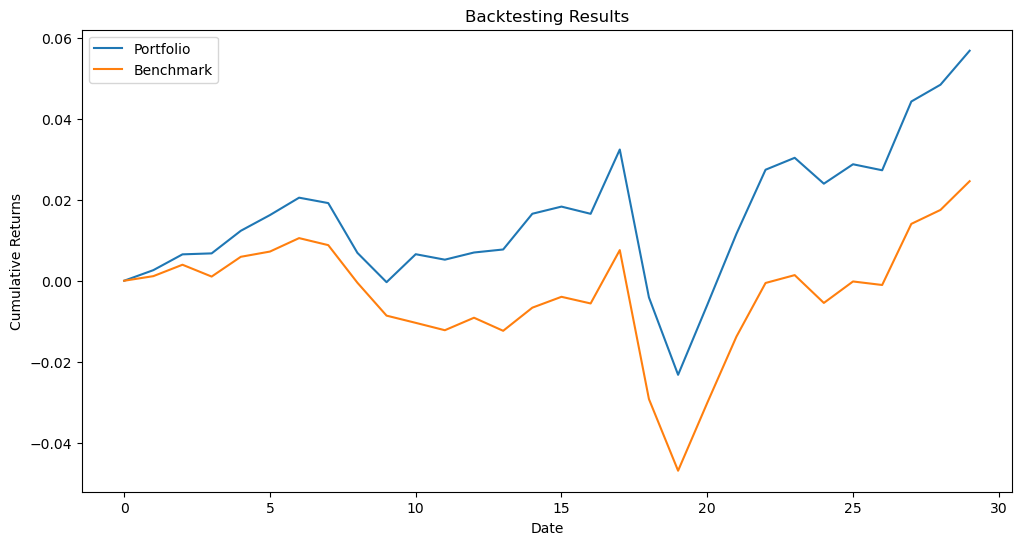


Period 10 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.005692
  Average weight: 0.001471
  Non-zero count: 680/680


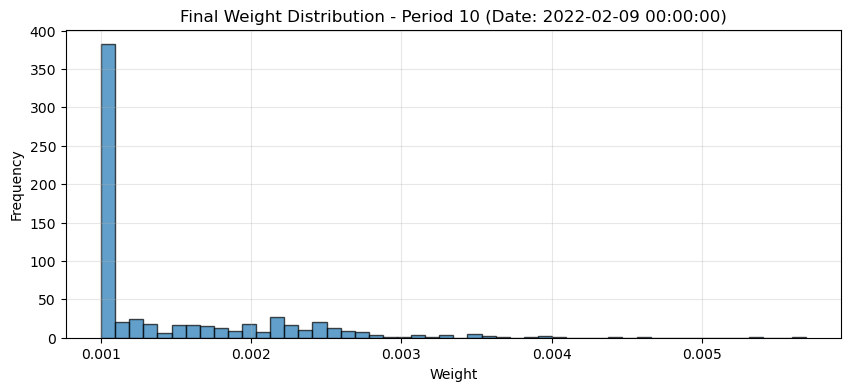

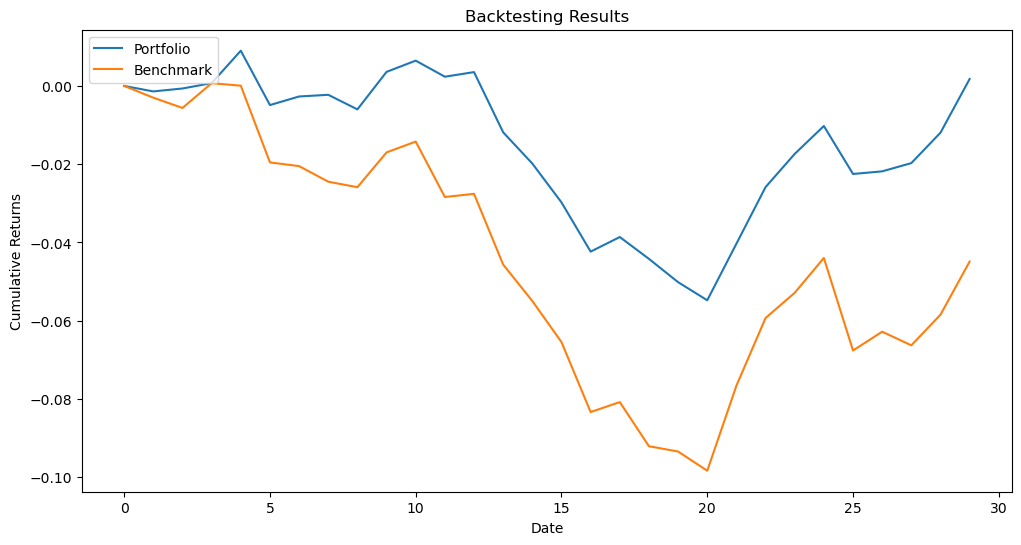

In [25]:
results_path_ga_wide = '../../results/qubo/results_ga_{}.pkl'
_ = run_experiment(results_path_ga_wide, df, benchmark, opt_fun_ga, parameters)

### BF

In [26]:

opt_fun_bf = partial(scipy_slsqp_qubo)


Period 1 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


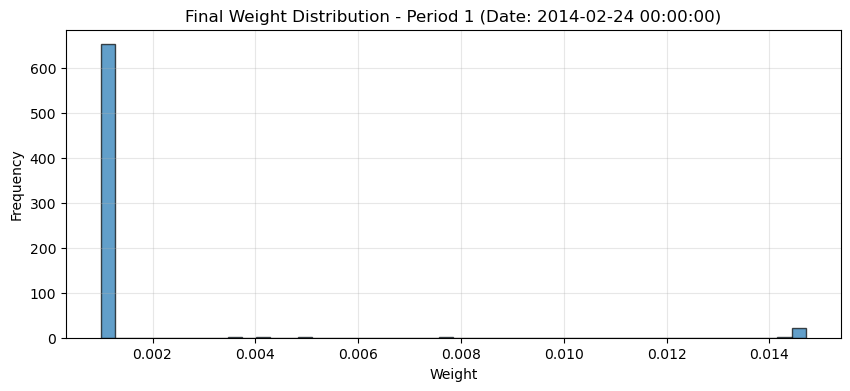

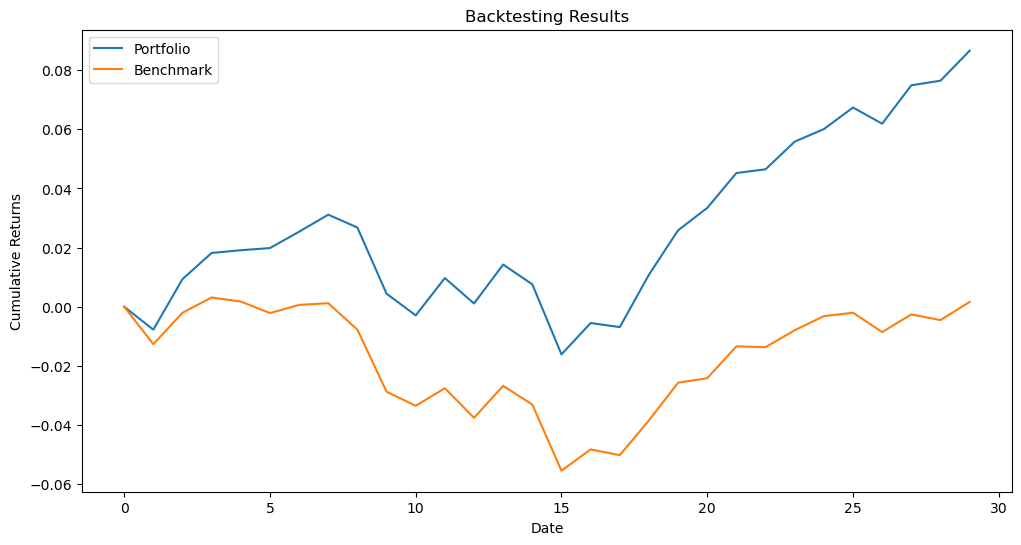


Period 2 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


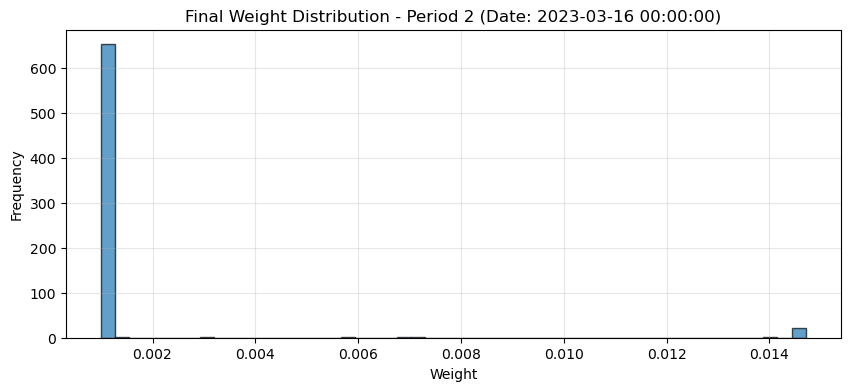

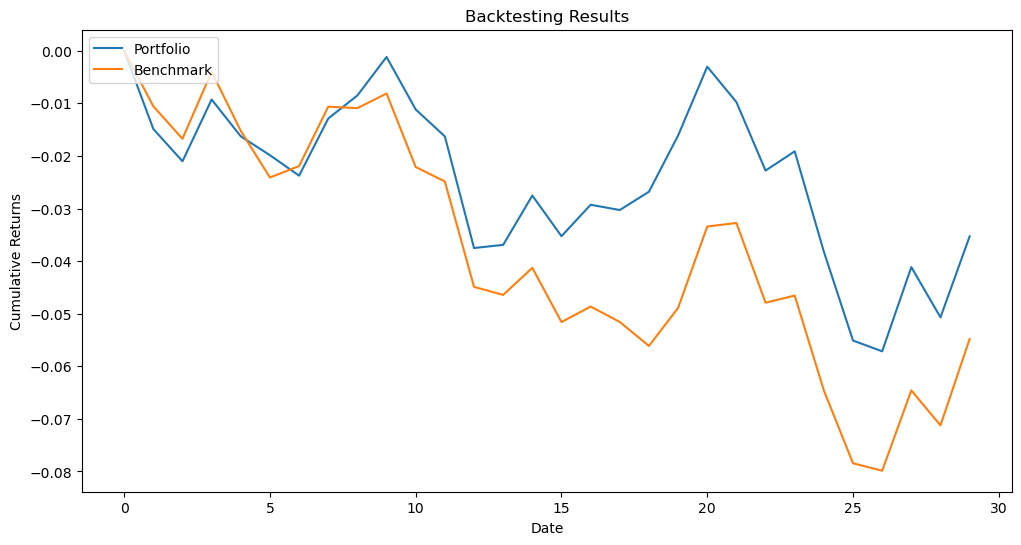


Period 3 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


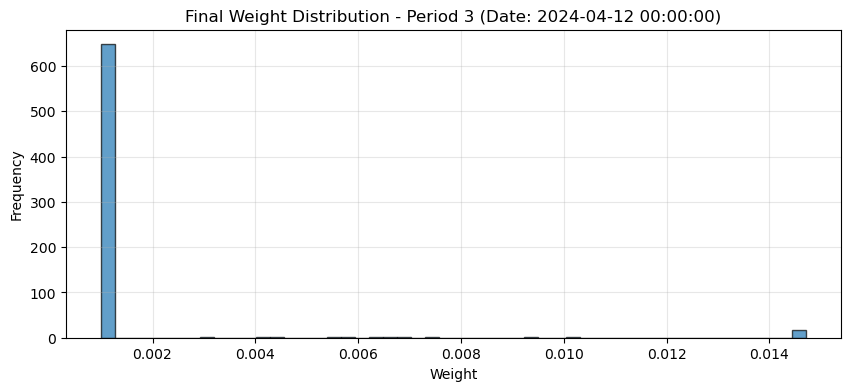

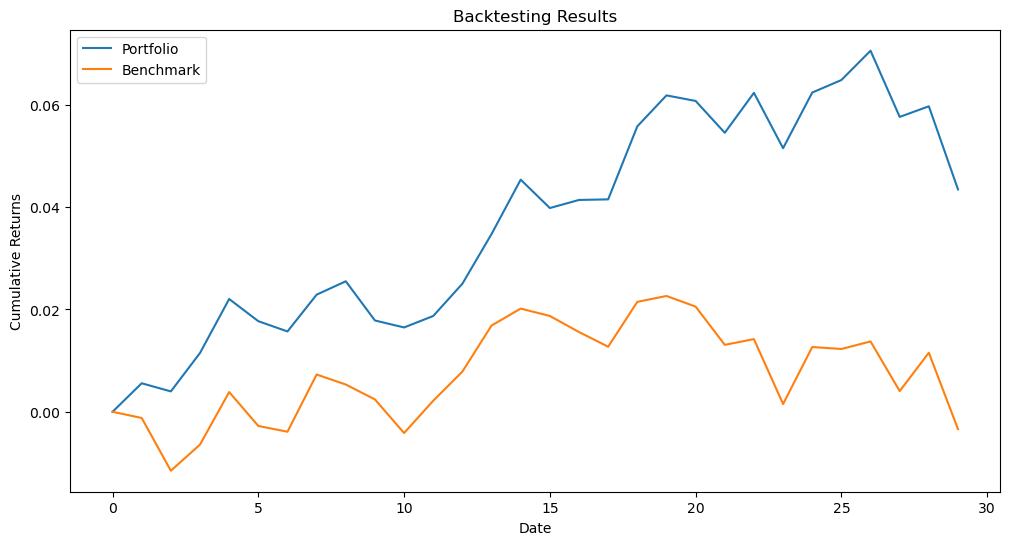


Period 4 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


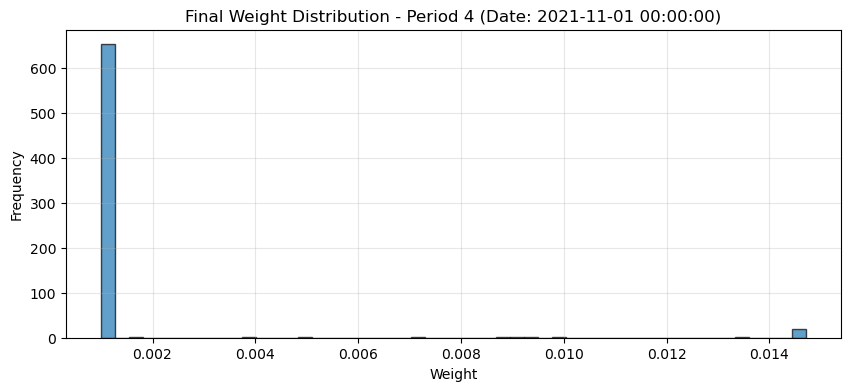

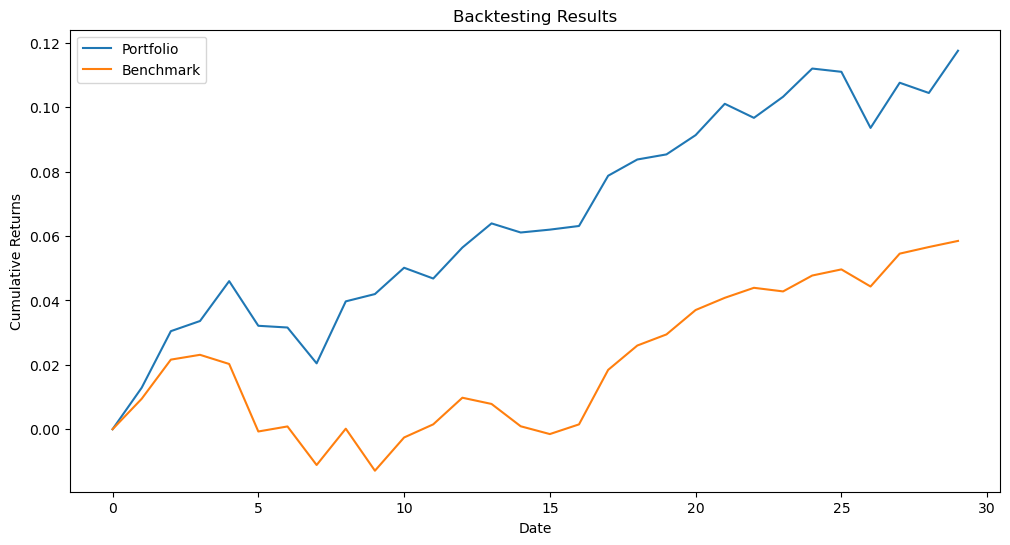


Period 5 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


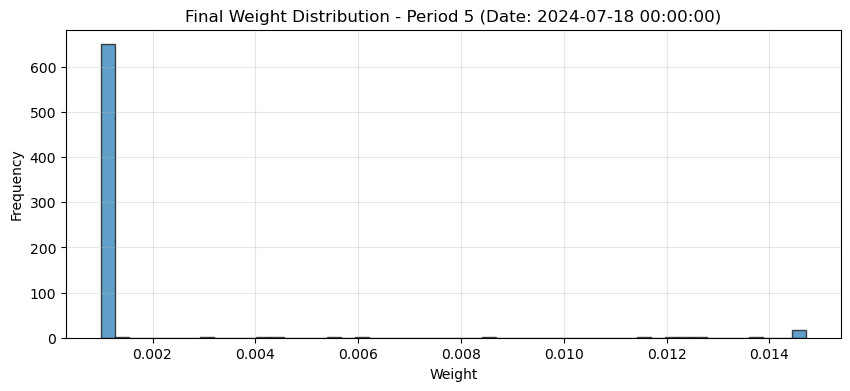

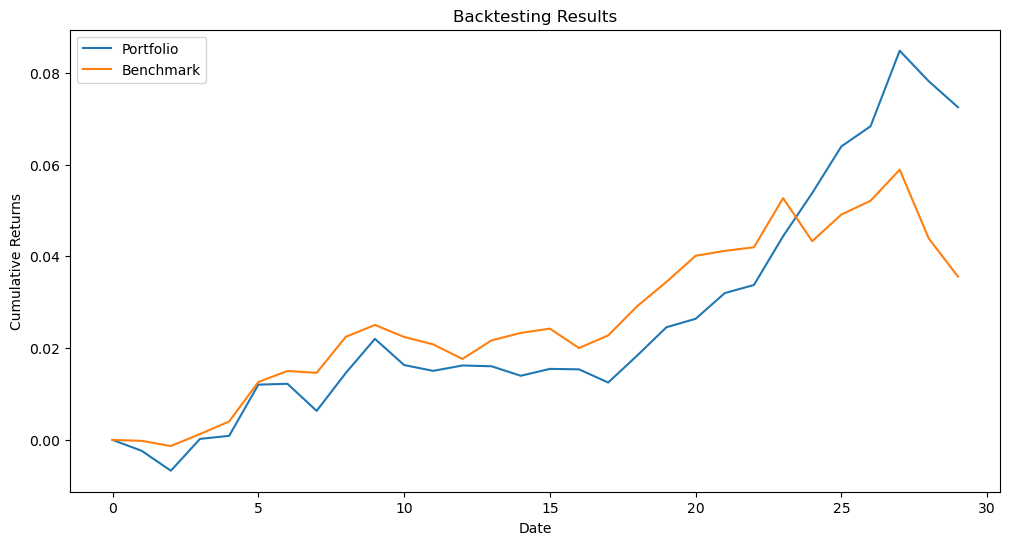


Period 6 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


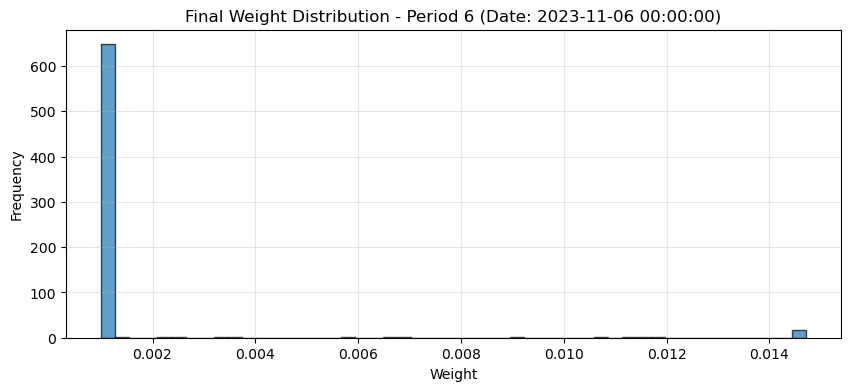

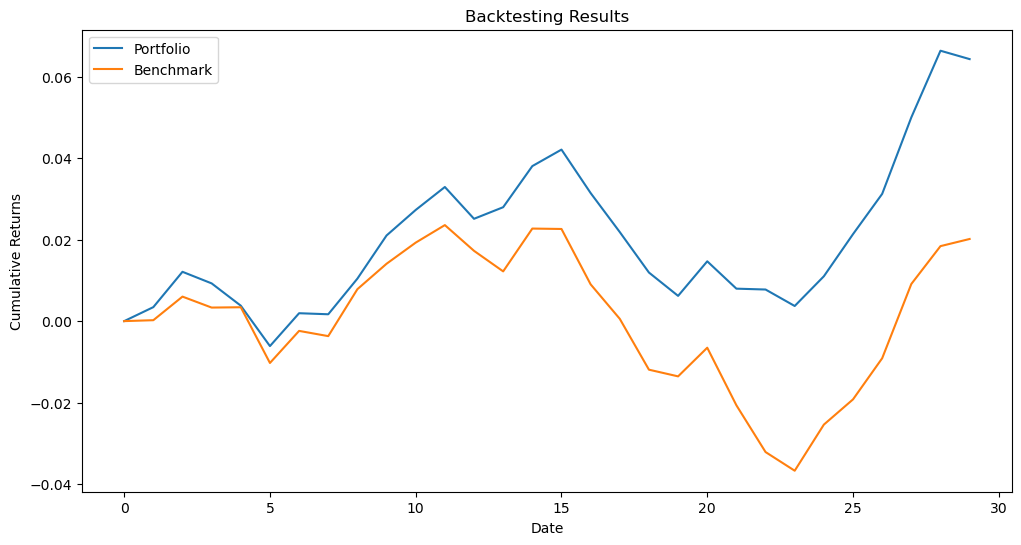


Period 7 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


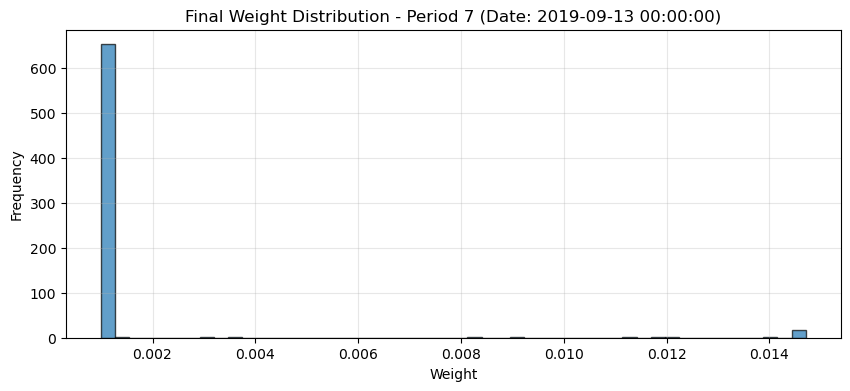

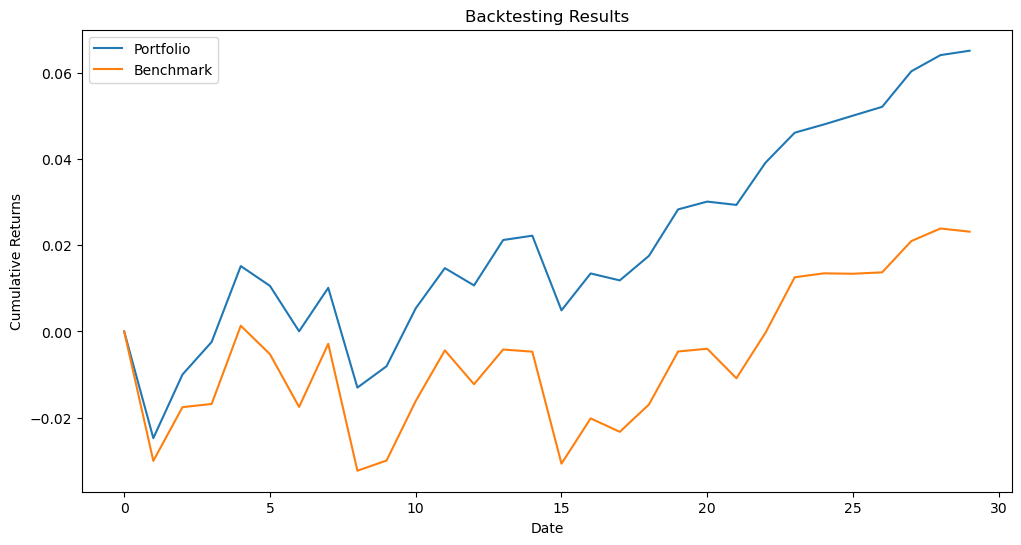


Period 8 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


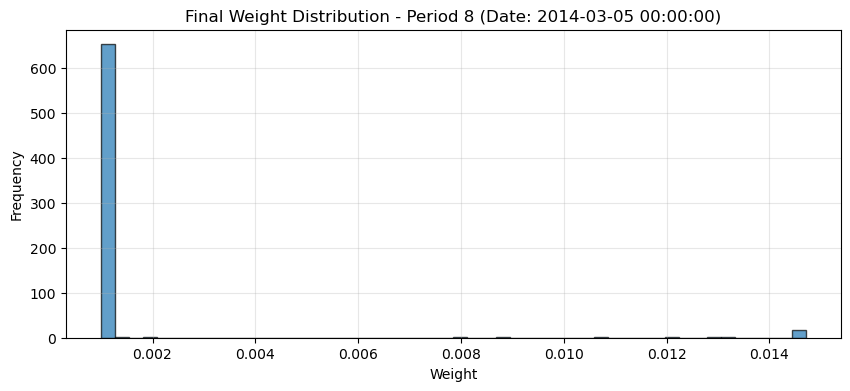

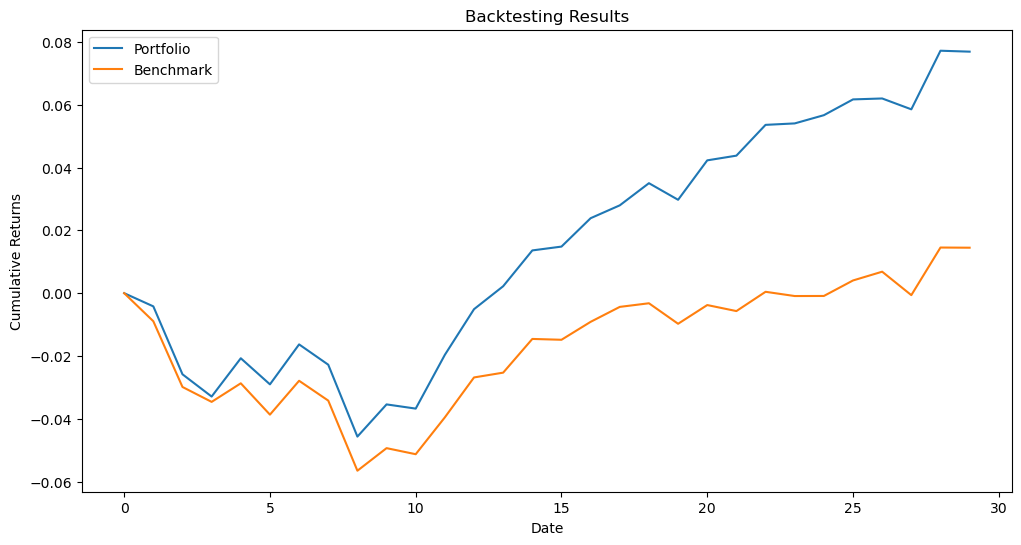


Period 9 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


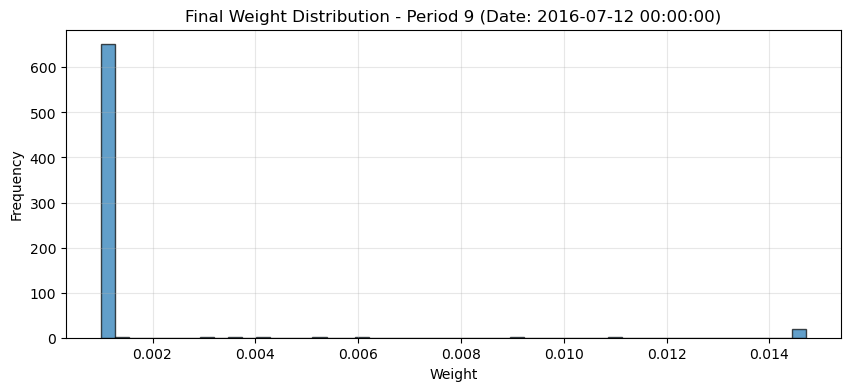

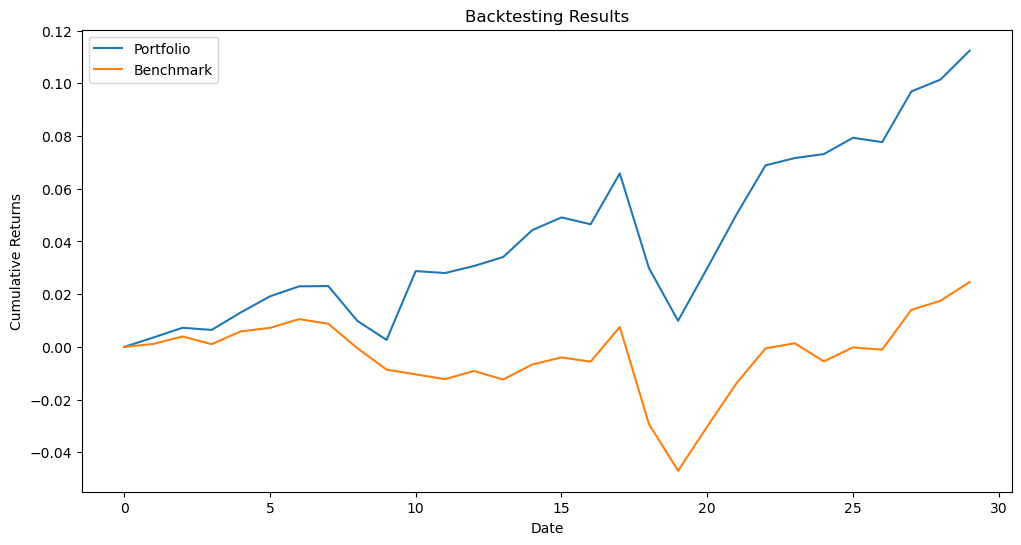


Period 10 Final Weights - Weight Statistics:
  Min weight:     0.001000
  Max weight:     0.014706
  Average weight: 0.001471
  Non-zero count: 680/680


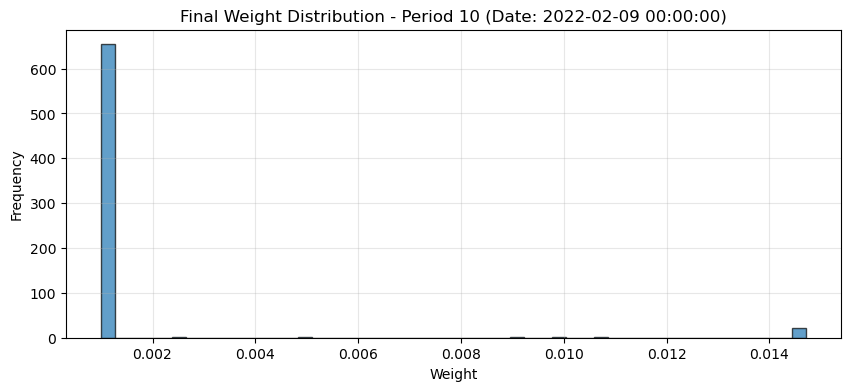

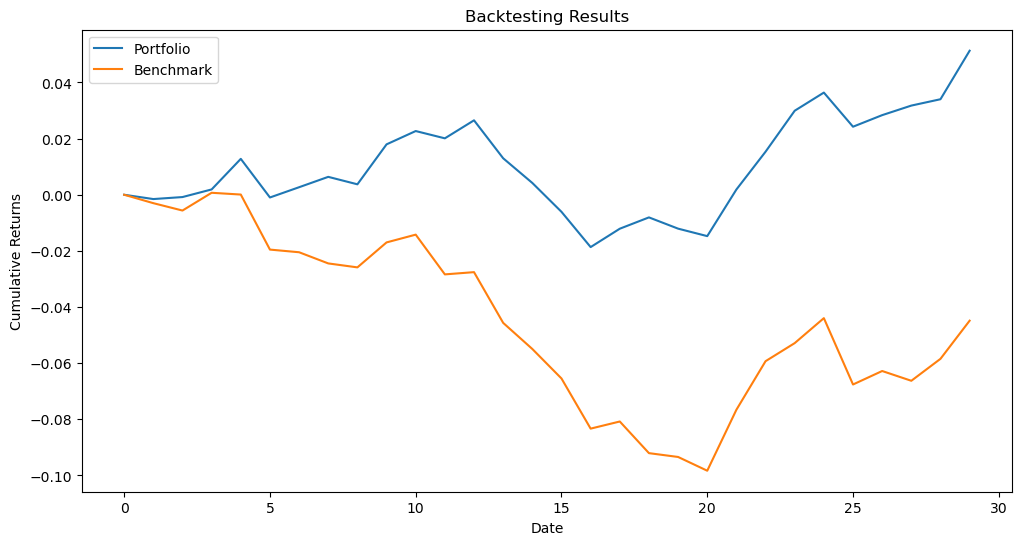

In [27]:
results_path_bf = '../../results/qubo/results_bf_{}.pkl'
_ = run_experiment(results_path_bf, df, benchmark, opt_fun_bf, parameters)

### Method comparison 

In [ ]:
# Comprehensive comparison of ALL optimization methods for Wide Dataset including Quantum
wide_dataset_solvers = [
    {'path_template': '../../results/qubo/results_ew_{}.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/qubo/results_ga_{}.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/qubo/results_bf_{}.pkl', 'name': 'Scipy SLSQP'},
]

n_periods = parameters['n_periods']
multi_comparison(wide_dataset_solvers, n_periods, "QUBO Optimization Methods (Wide Dataset - Stocks + ETFs)")

# Generate comprehensive performance summary
print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Wide Dataset - Stocks + ETFs)")
print("="*100)
summary_df = performance_summary(wide_dataset_solvers, n_periods)
if not summary_df.empty:
    # Sort by average return for better readability
    summary_df_sorted = summary_df.sort_values('Avg_Return', ascending=False)
    display(summary_df_sorted)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df)}")
    print(f"Best performer: {summary_df_sorted.iloc[0]['Solver']} (avg return: {summary_df_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df.loc[summary_df['Avg_Time'].idxmin(), 'Solver']} ({summary_df['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df.loc[summary_df['Success_Rate'].idxmax(), 'Solver']} ({summary_df['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")

### Experiment 2: Synthetic Dataset with 1000 securities 

In [31]:
source_synth_path = "../../data/synthetic_close.pkl"

In [32]:
source_synth = pd.read_pickle(source_synth_path)
source_synth.head()

,ds,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
0,2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
1,2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2,2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
3,2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
4,2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


In [33]:
print(source_synth.shape)
# Check if any row contains at least one NaN
#print(source_wide.isnull().any(axis=1))
# Check if any value in the DataFrame is null
has_any_nan = source_synth.isnull().values.any()
print("Any NaN in source_synth:", has_any_nan)
source_synth.head()

(3521, 1201)
Any NaN in source_synth: False


,ds,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
0,2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
1,2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2,2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
3,2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
4,2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


In [34]:
df_synth = source_synth
df_synth.set_index('ds', inplace=True)
days_to_avg = parameters['days_to_avg']
display(df_synth.head())
has_any_nan = source_synth.isnull().values.any()
print("Any NaN in source_synth:", has_any_nan)
print(f'initial date: {df_synth.iloc[days_to_avg+1, :].index}')

,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,18.107629,75.492461,129.462925,125.937036,87.798646,98.343111,125.783745,17.166407,145.878215,190.952276
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,18.030430,75.850052,128.858985,124.957257,87.413089,98.193005,125.538872,17.047364,145.654602,191.300773
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,17.971160,76.258827,128.802213,124.441944,87.940231,97.989877,125.854862,16.999914,146.992259,191.298014
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,17.821023,76.472465,129.117381,124.334951,87.966434,97.917770,125.800167,17.030518,148.804873,190.944464
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,17.680604,76.430398,129.274692,124.344211,88.868399,97.893132,126.111993,17.036943,151.627367,189.739391


Any NaN in source_synth: False
initial date: Index(['A', 'AAPL', 'ABT', 'ACGL', 'ACN', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK',
       ...
       'FUND_906_RATIO', 'CMWQ', 'UAA_VOL', 'XEB', 'ETF_609', 'STOCK_442',
       'ECFE', 'REIT_677_PRICE', 'OVDJ', 'QMCFQ'],
      dtype='object', length=1200)


<Axes: xlabel='ds'>

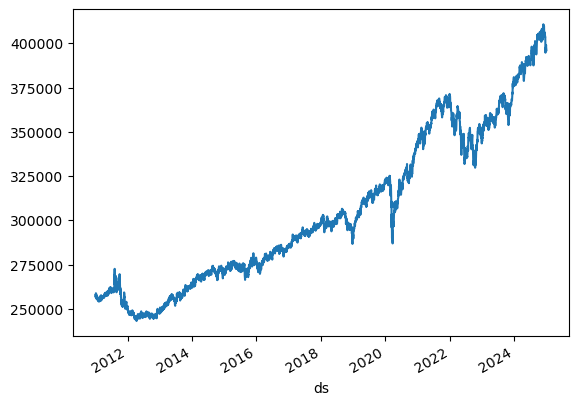

In [35]:
df_synth.sum(axis=1).plot()

Resetting parameters. The total cost of 10k stocks is more than 1E6 which prevents the portfolio from covering all stocks if the budget is 1E6 and the weights are integers. 

In [36]:
parameters = {
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "n_periods": 10,
    "days_to_avg": 30,
    "days_to_opt": 30,
    "budget": 10_000_000,
}

In [37]:
data_gen = generate_data(df_synth, benchmark, days_to_avg=30, days_to_opt=30, seed=SEED)
df, df_b = next(data_gen)
df.tail()

,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,FUND_906_RATIO,CMWQ,UAA_VOL,XEB,ETF_609,STOCK_442,ECFE,REIT_677_PRICE,OVDJ,QMCFQ
ds,,,,,,,,,,,,,,,,,,,,,
2014-02-18,35.987545,17.094862,31.480751,17.727919,68.256264,68.660004,40.423801,29.707829,52.764717,54.520000,...,16.491393,51.196646,294.039336,330.510589,99.858985,139.814198,155.204728,18.475895,70.671243,284.468809
2014-02-19,36.503075,16.824974,31.343287,17.502872,68.809998,67.989998,40.692089,29.282701,52.530193,54.470001,...,16.396301,50.914023,296.626714,331.025651,102.022585,139.793969,156.240165,18.340819,71.446138,283.258807
2014-02-20,37.383987,16.630224,31.496935,17.651846,68.909180,68.480003,40.557964,29.407299,52.778519,54.900002,...,16.367533,50.758845,299.762204,331.668085,103.939102,139.940008,157.052182,18.483789,72.910436,281.710411
2014-02-21,36.764088,16.445498,31.391796,17.705730,69.256287,68.220001,40.337021,29.312025,52.564671,55.400002,...,16.329645,50.457478,301.650829,332.112890,105.442671,140.278673,157.946203,18.652996,73.970279,279.684075
2014-02-24,37.031612,16.517513,31.521198,17.506042,69.380234,68.769997,40.210762,29.436628,52.978558,54.470001,...,16.347139,50.080086,301.413926,332.257976,107.335604,140.353310,158.403707,18.651485,75.323218,278.148884


#### Equal Weights baseline


Period 1 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


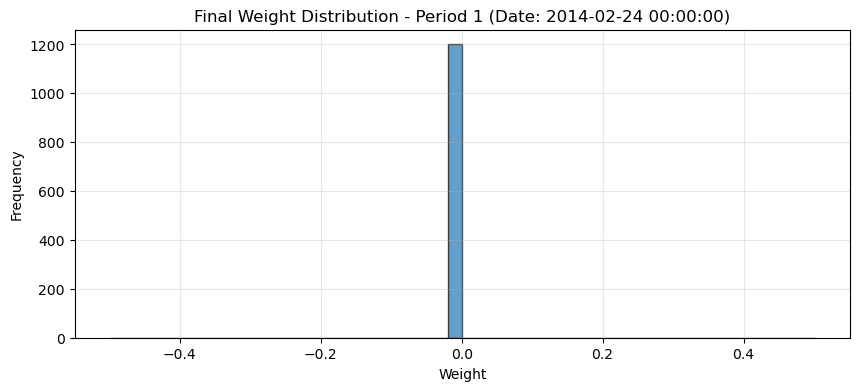

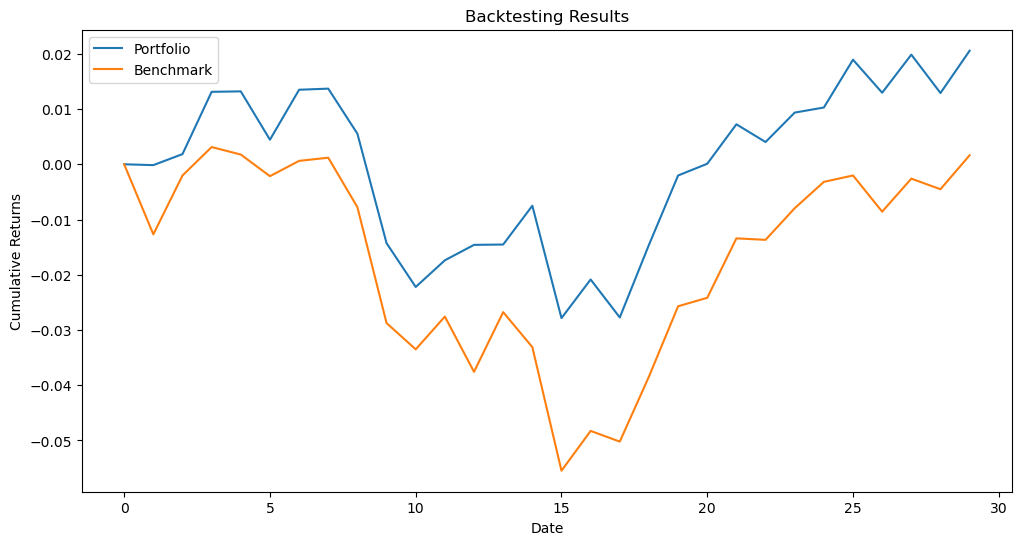


Period 2 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


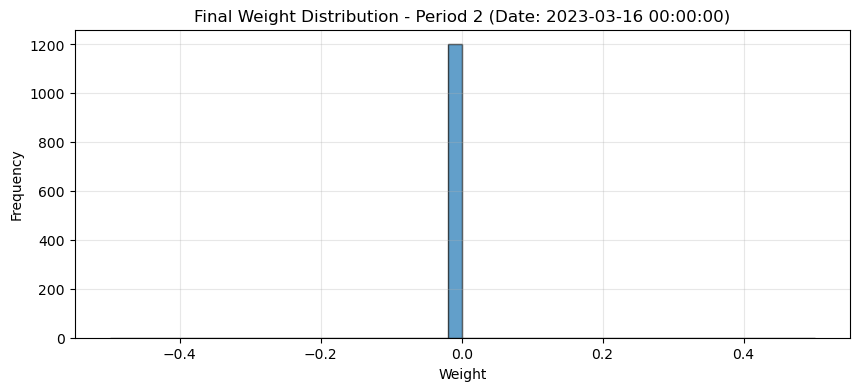

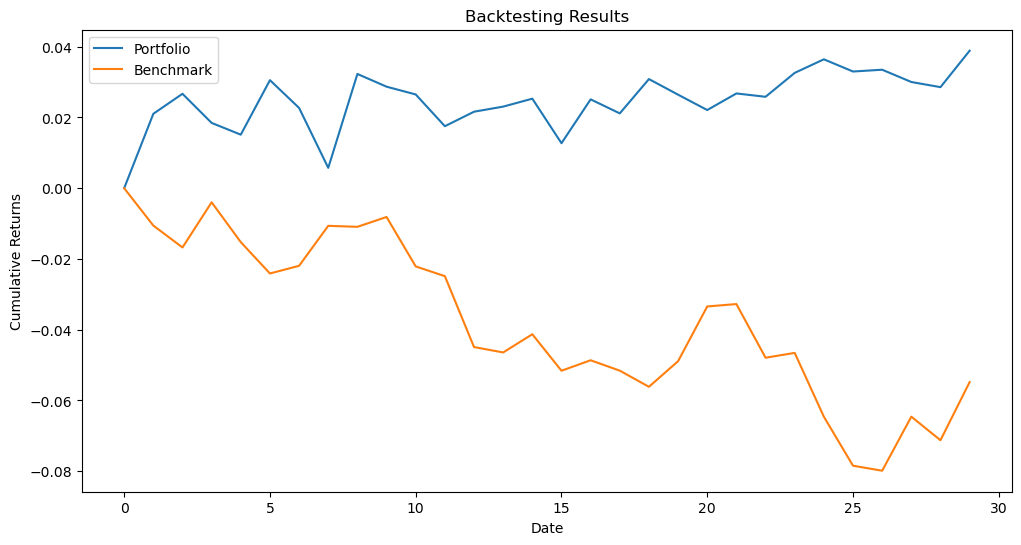


Period 3 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


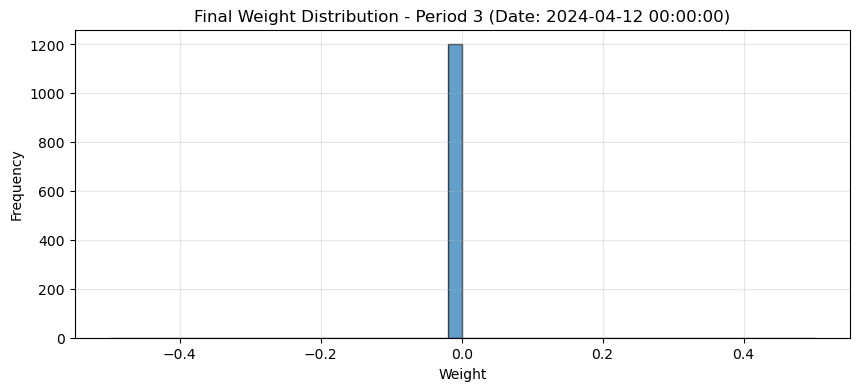

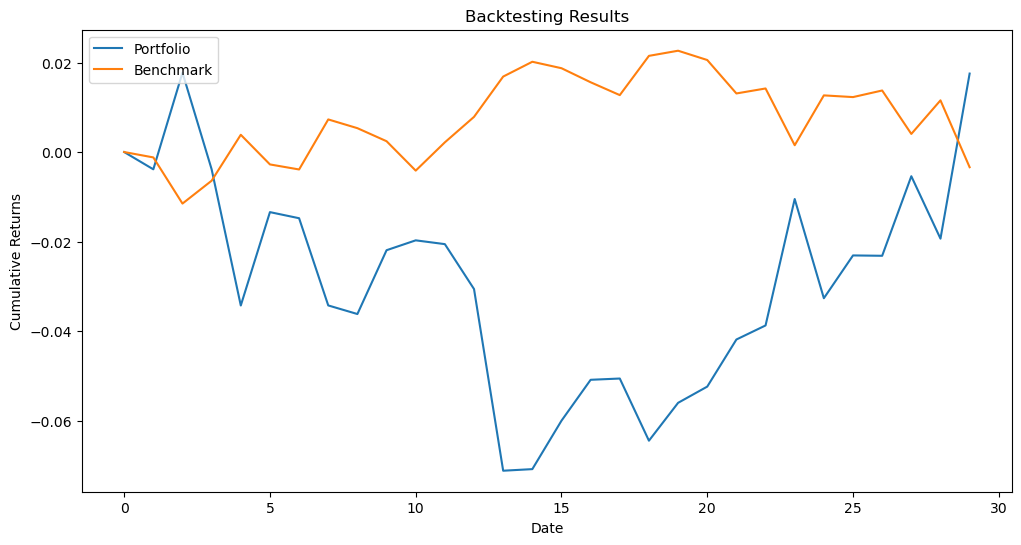


Period 4 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


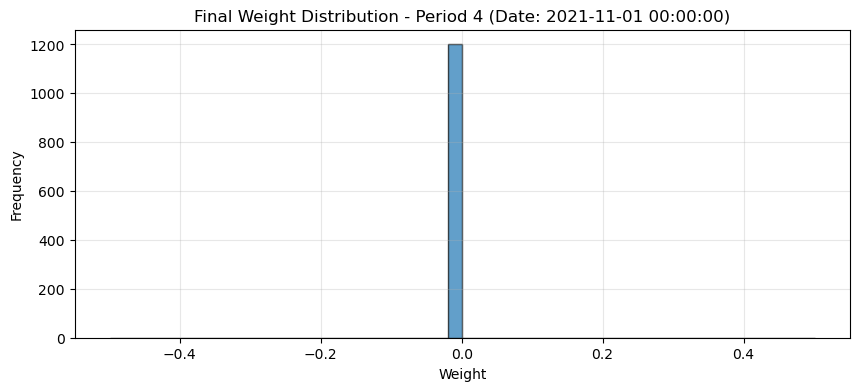

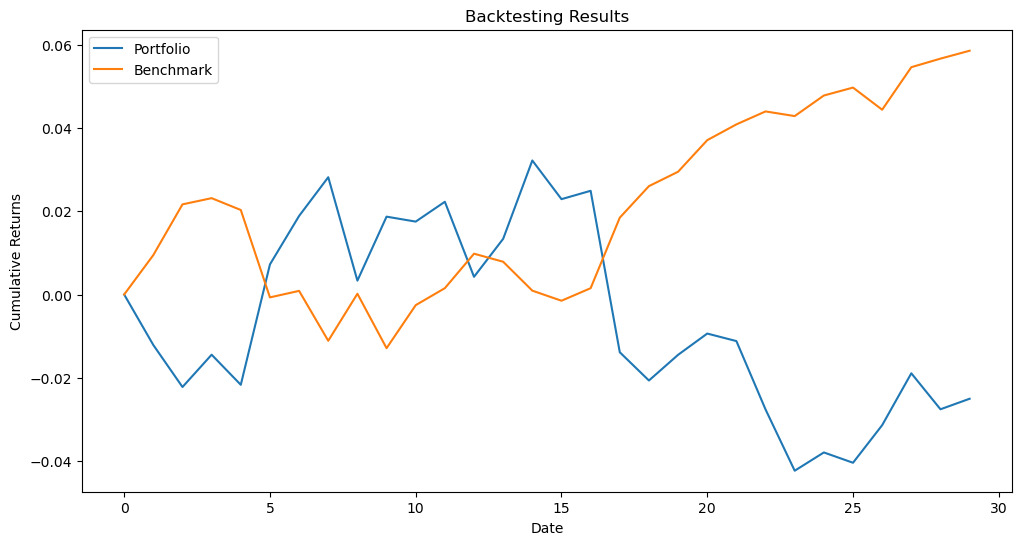


Period 5 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


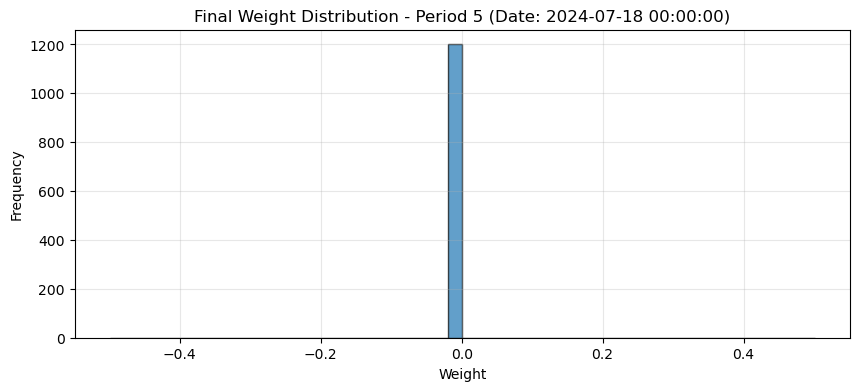

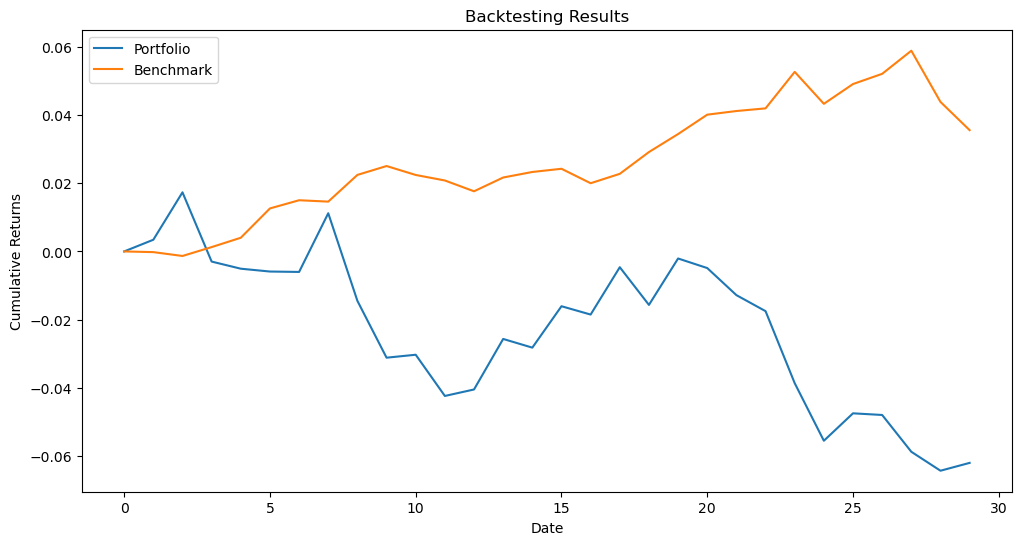


Period 6 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


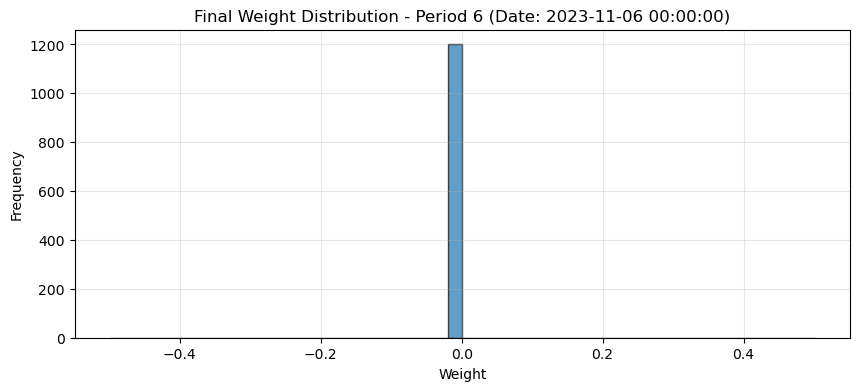

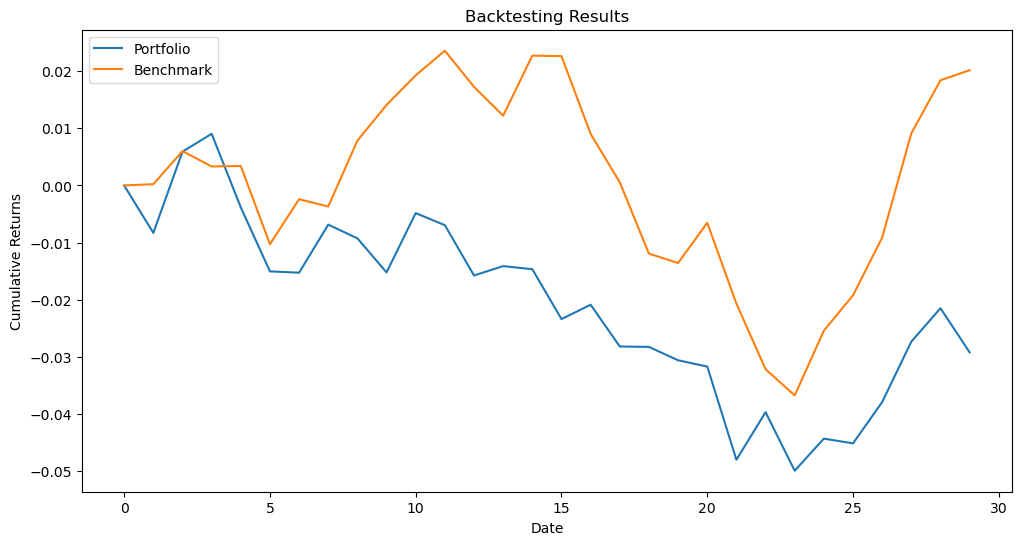


Period 7 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


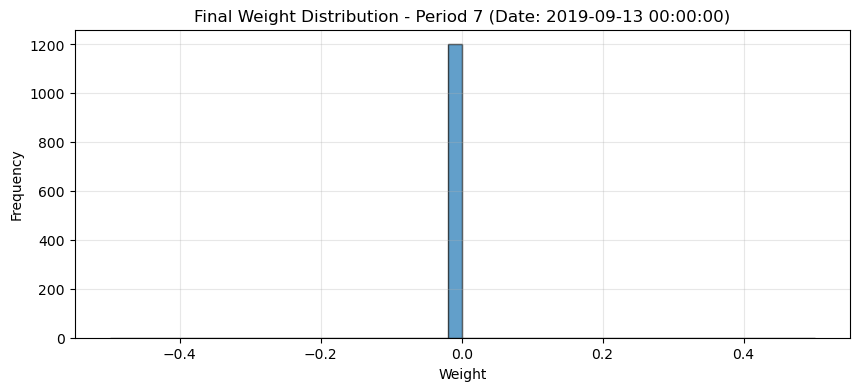

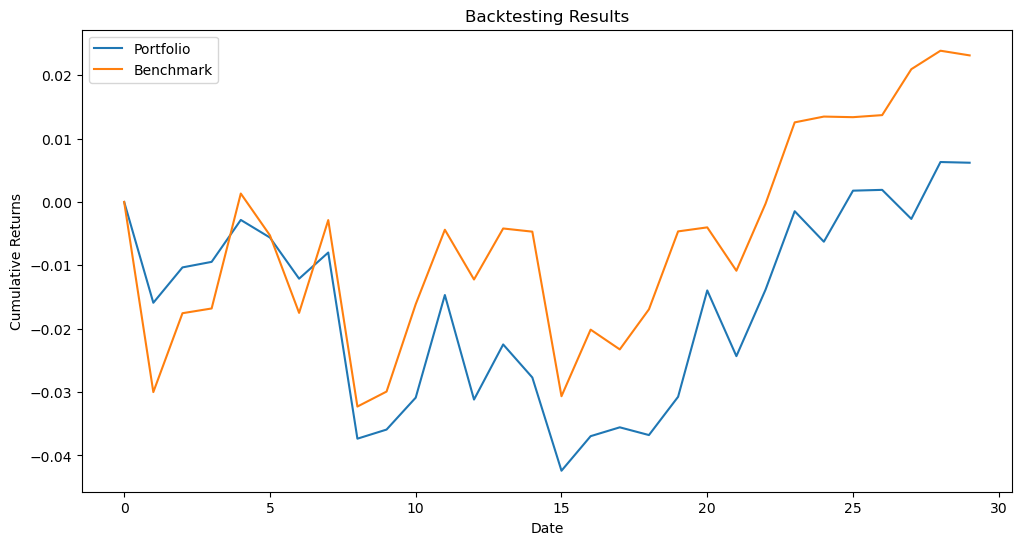


Period 8 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


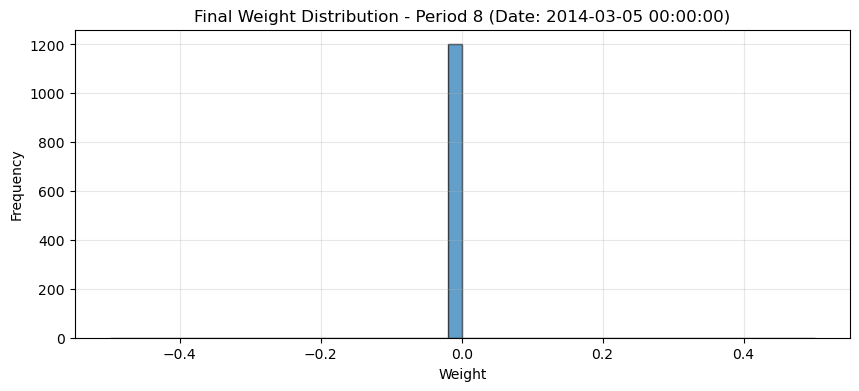

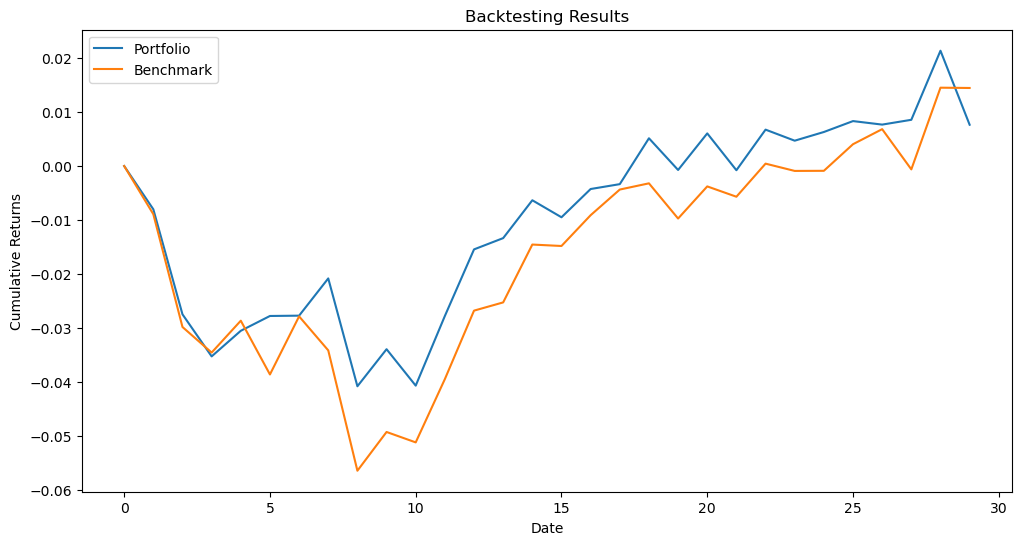


Period 9 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


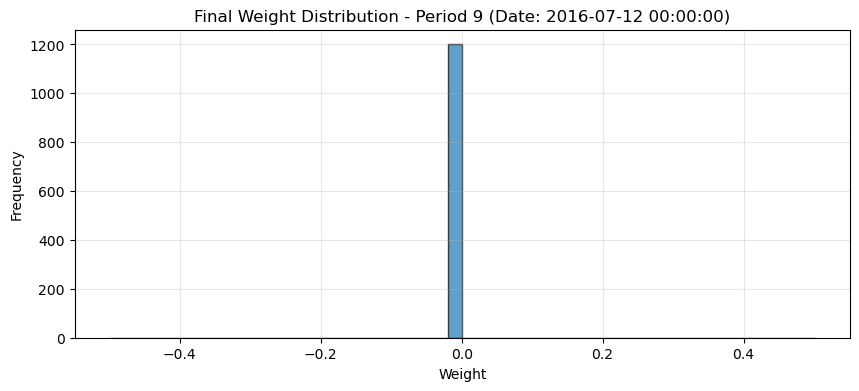

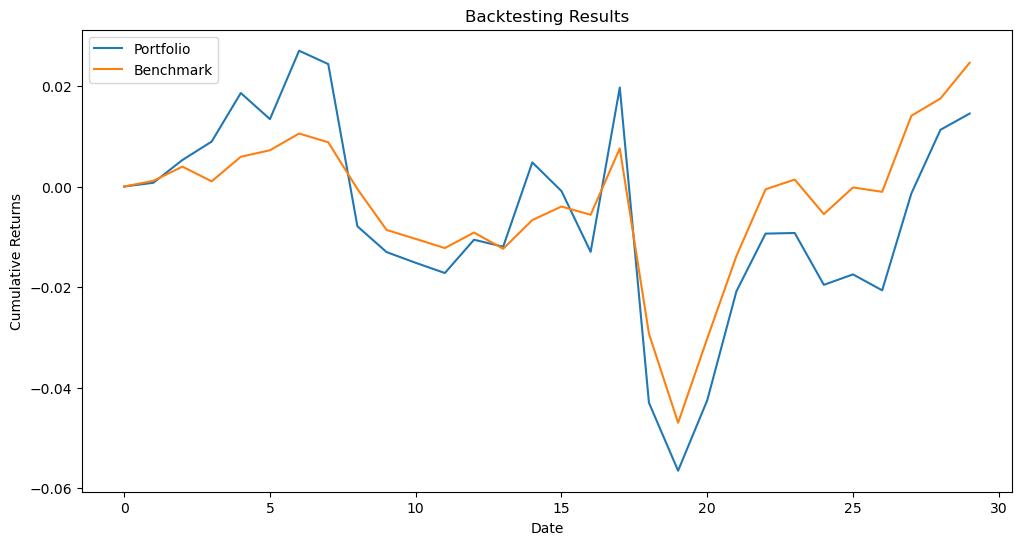


Period 10 Final Weights - Weight Statistics:
  Min weight:     0.000833
  Max weight:     0.000833
  Average weight: 0.000833
  Non-zero count: 1200/1200


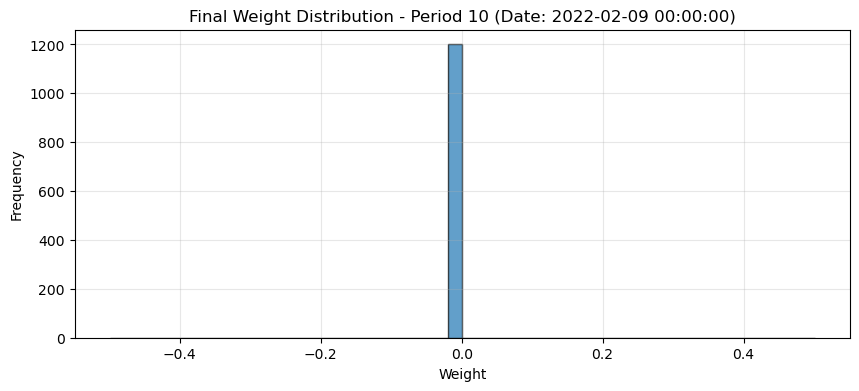

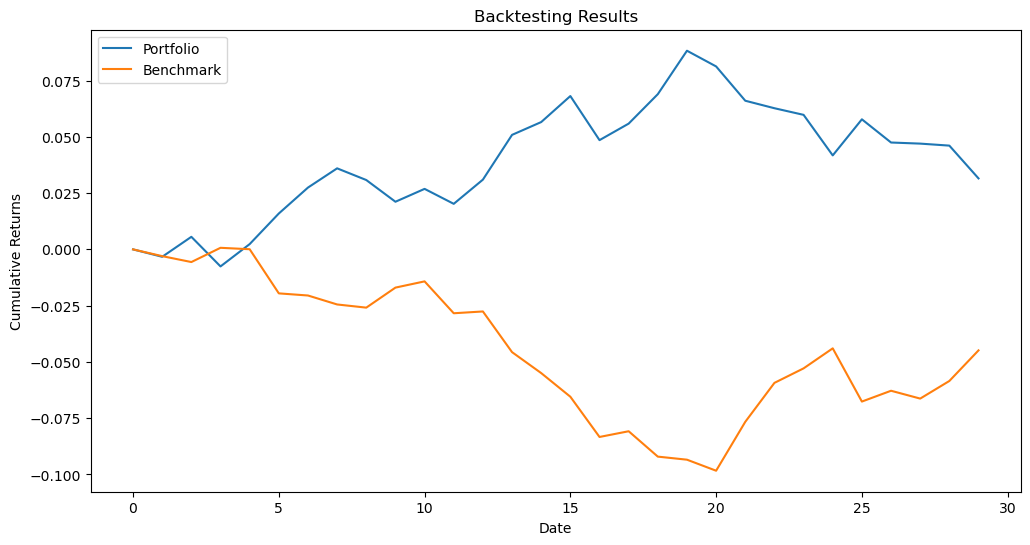

In [38]:
results_path_ew_synth = '../../results/qubo/results_synth_ew_{}.pkl'
_ = run_experiment(results_path_ew_synth, df_synth, benchmark, opt_fun_ew, parameters)

#### GA Synth

initial date: 2014-01-13 00:00:00


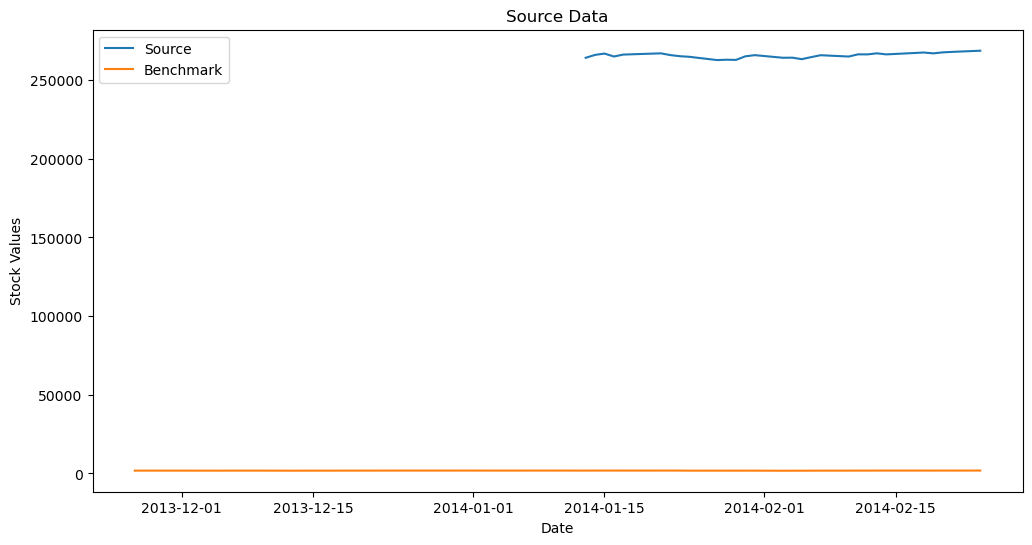

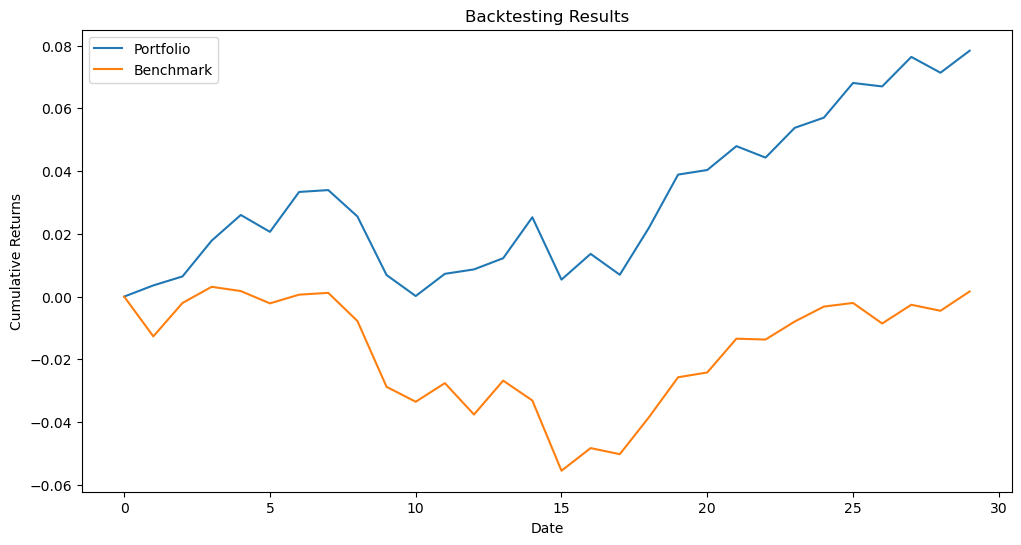

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_0.pkl

Period 1 Final Weights - Weight Statistics:
  Min weight:     0.000701
  Max weight:     0.002400
  Average weight: 0.000833
  Non-zero count: 1200/1200


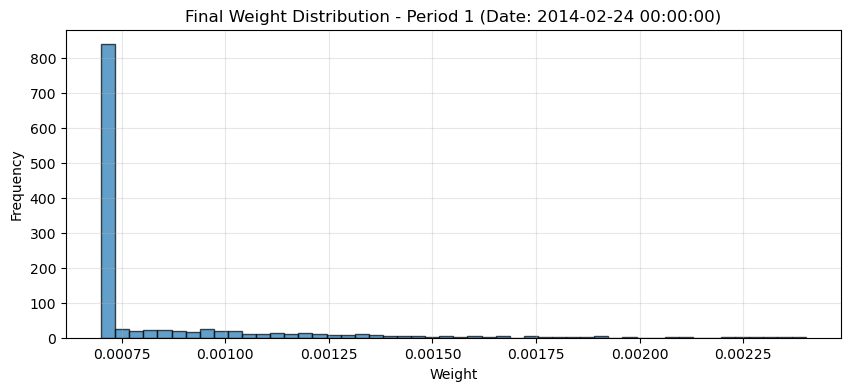

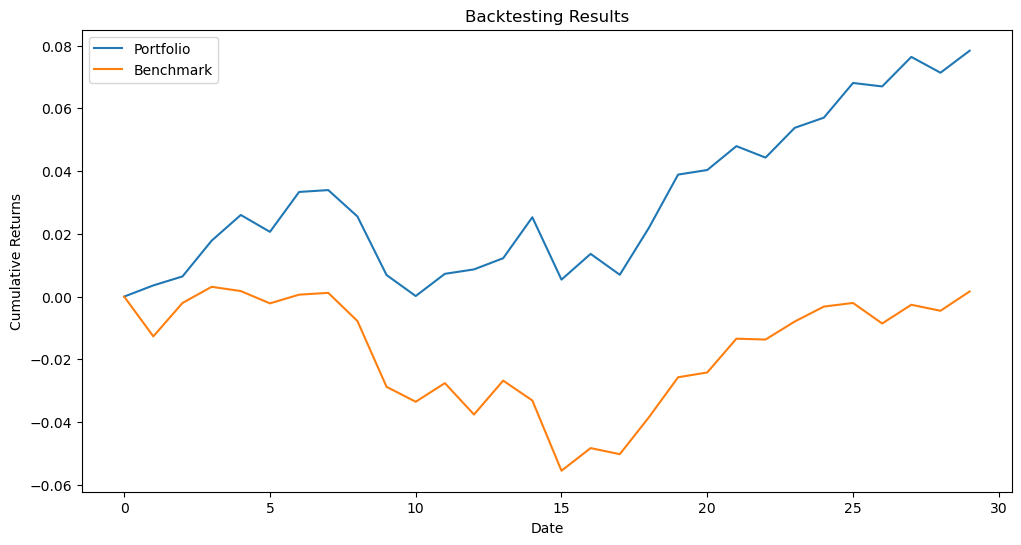

initial date: 2023-02-03 00:00:00


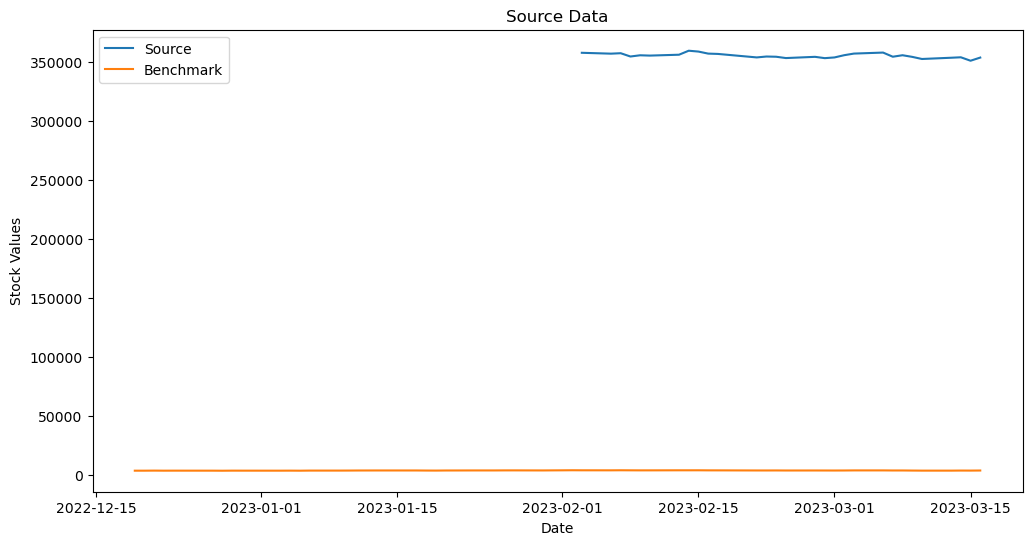

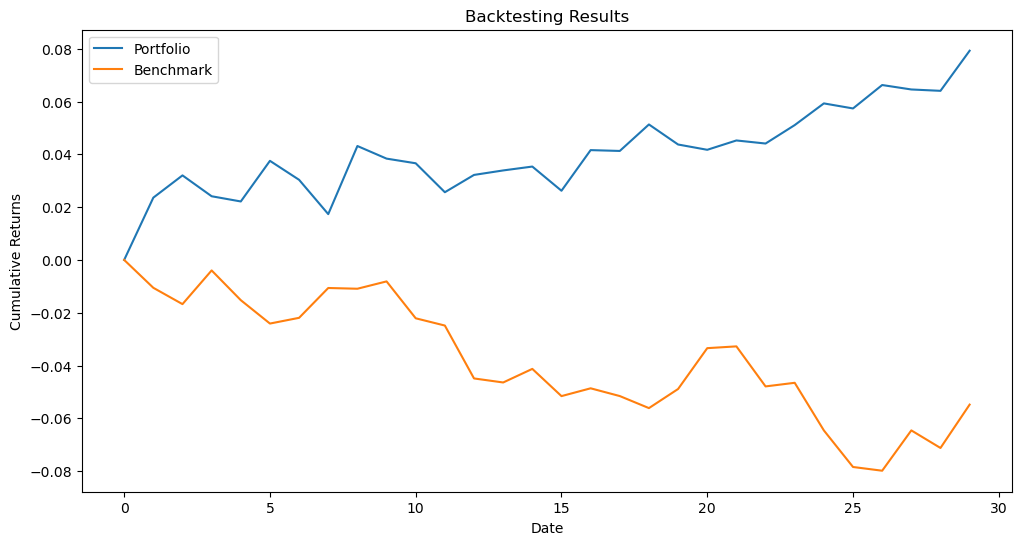

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_1.pkl

Period 2 Final Weights - Weight Statistics:
  Min weight:     0.000695
  Max weight:     0.002280
  Average weight: 0.000833
  Non-zero count: 1200/1200


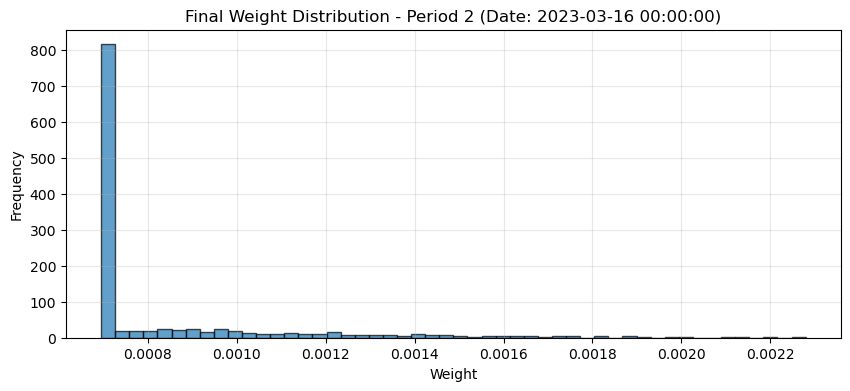

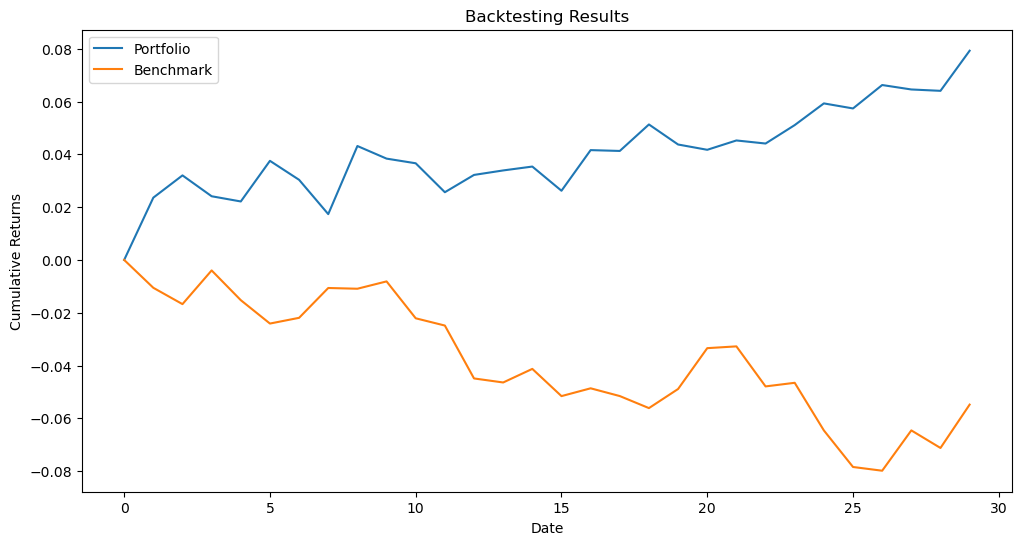

initial date: 2024-03-04 00:00:00


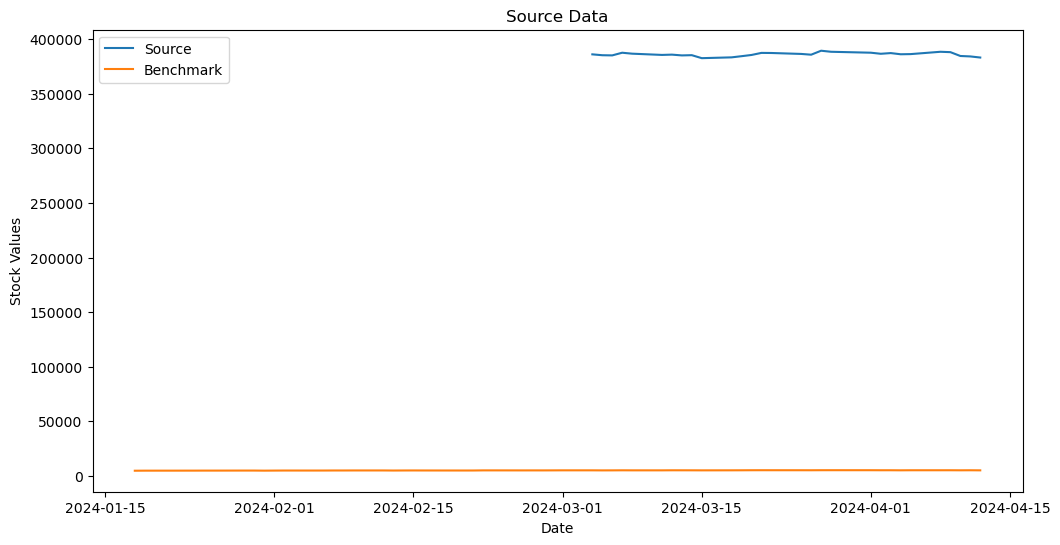

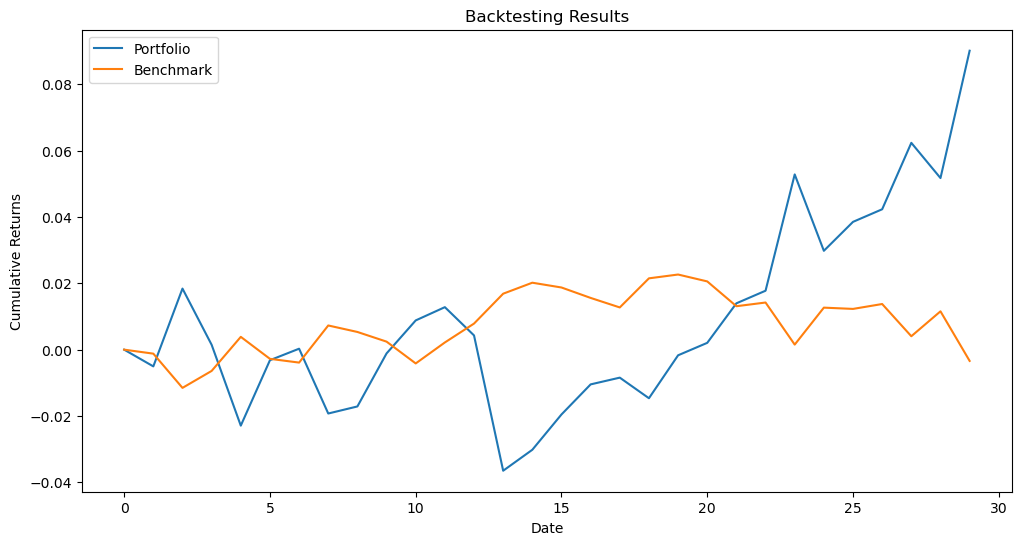

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_2.pkl

Period 3 Final Weights - Weight Statistics:
  Min weight:     0.000703
  Max weight:     0.002556
  Average weight: 0.000833
  Non-zero count: 1200/1200


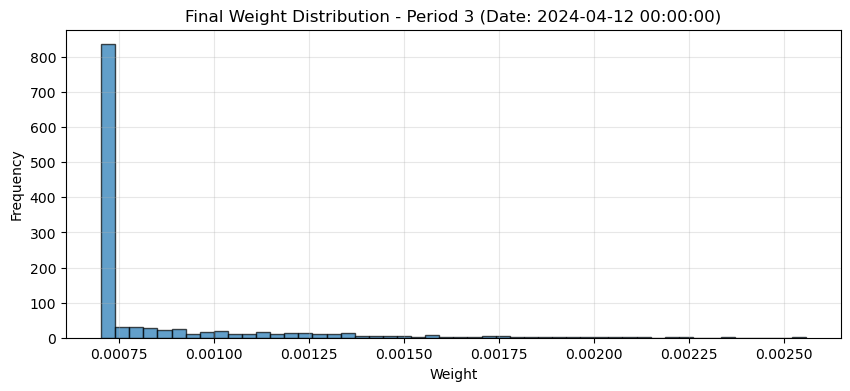

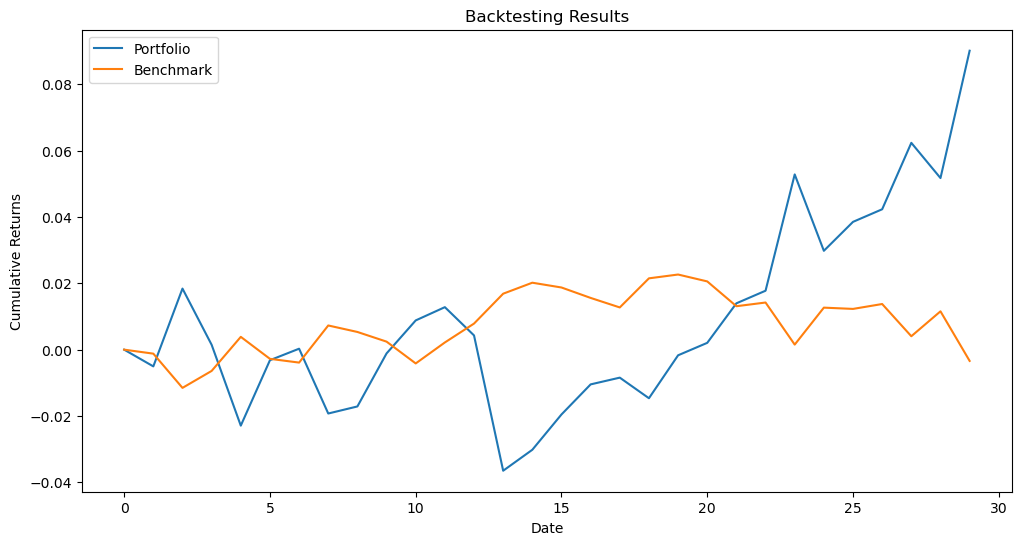

initial date: 2021-09-22 00:00:00


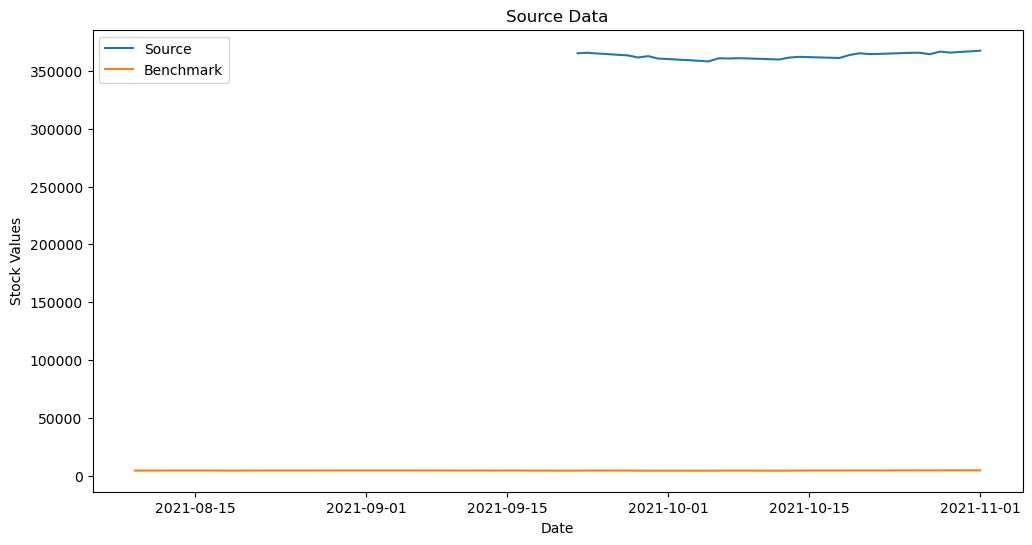

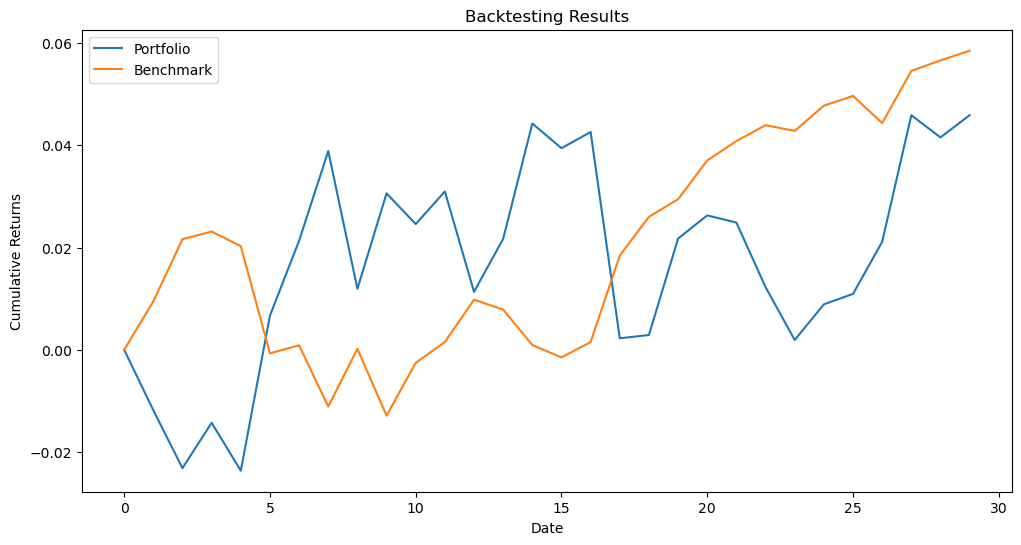

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_3.pkl

Period 4 Final Weights - Weight Statistics:
  Min weight:     0.000706
  Max weight:     0.002919
  Average weight: 0.000833
  Non-zero count: 1200/1200


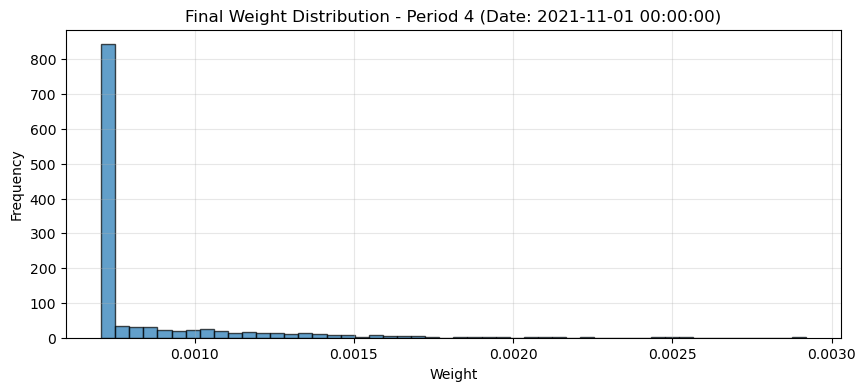

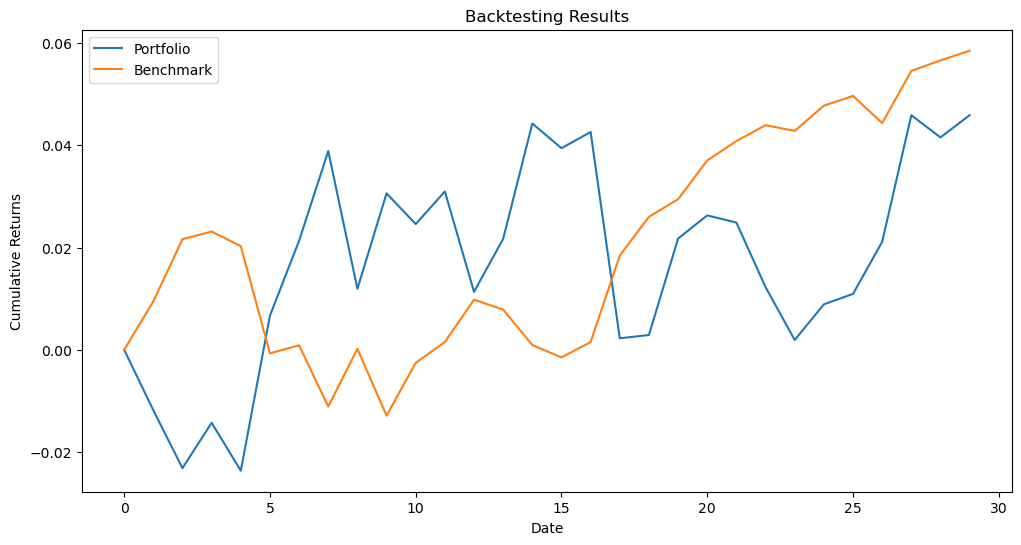

initial date: 2024-06-06 00:00:00


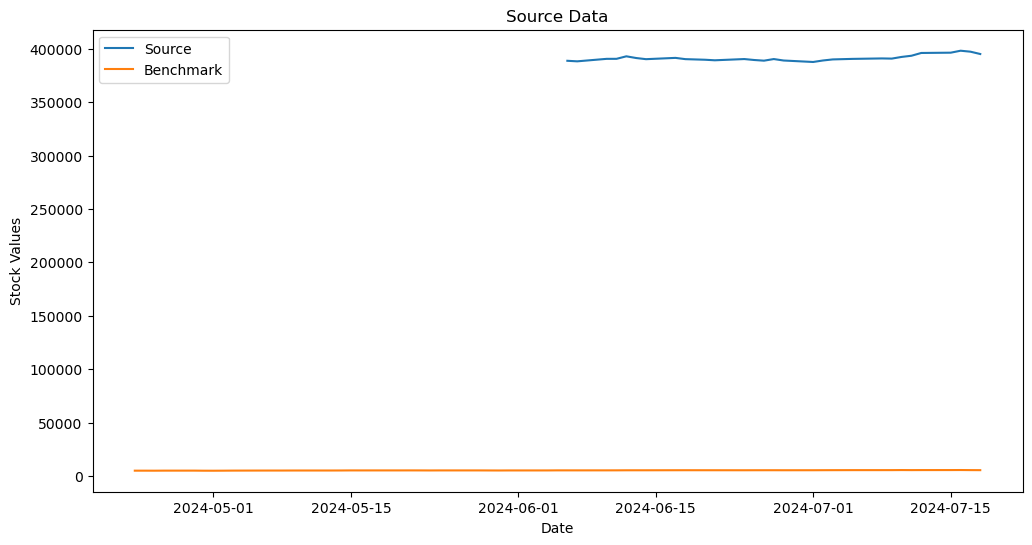

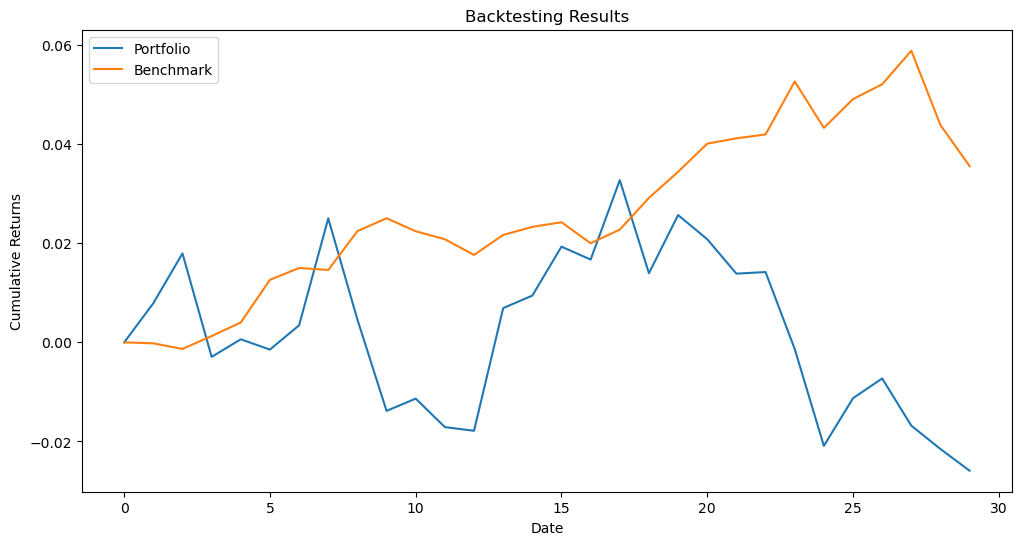

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_4.pkl

Period 5 Final Weights - Weight Statistics:
  Min weight:     0.000703
  Max weight:     0.002857
  Average weight: 0.000833
  Non-zero count: 1200/1200


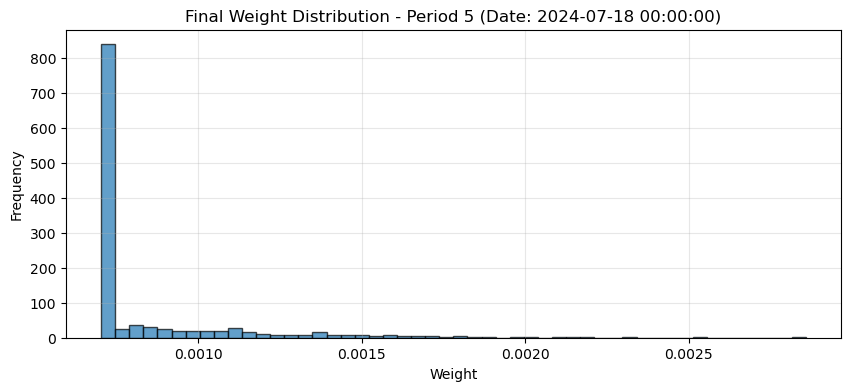

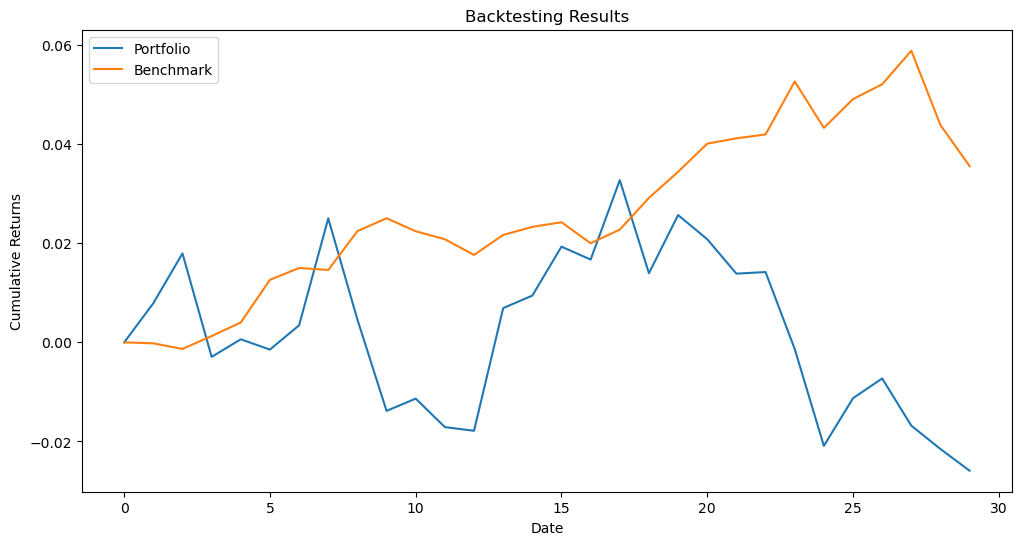

initial date: 2023-09-27 00:00:00


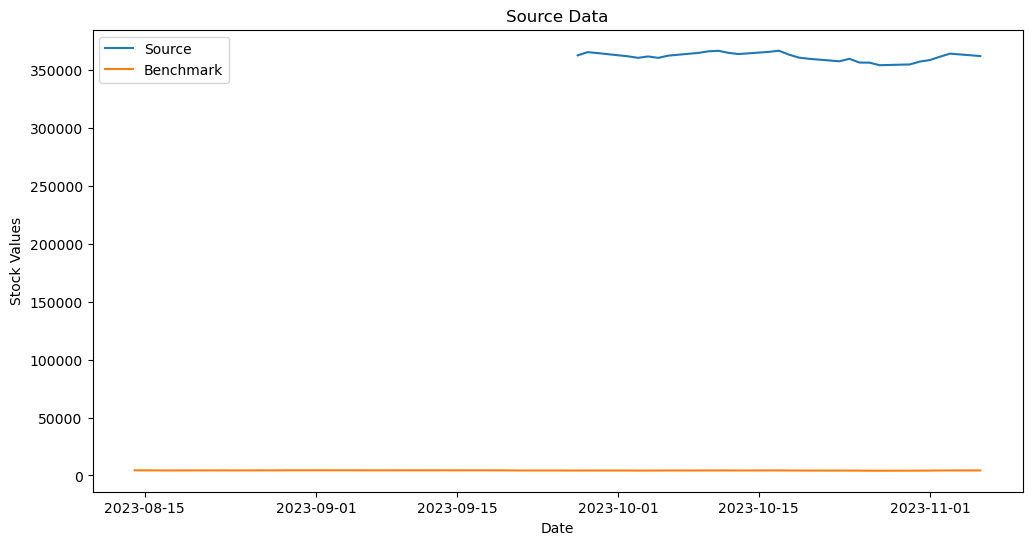

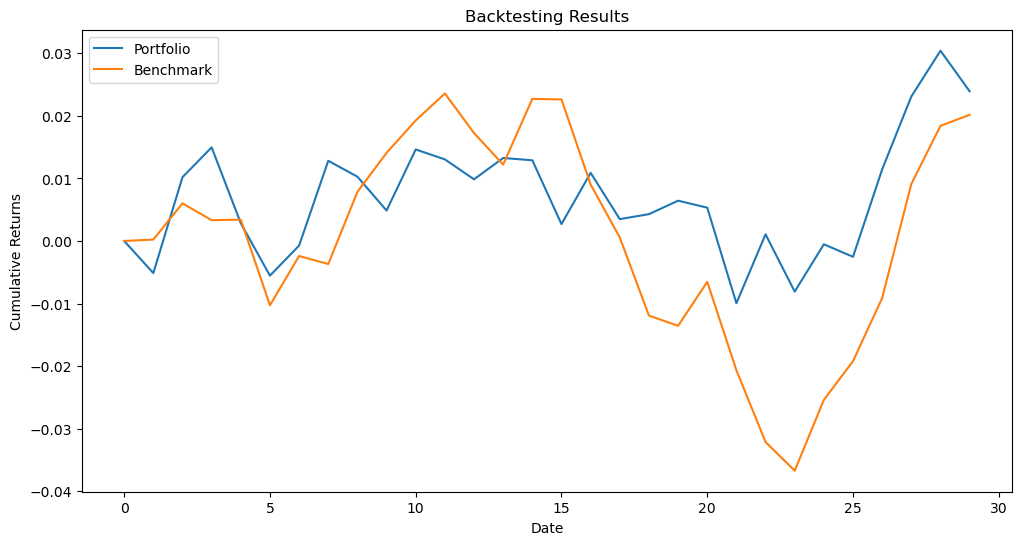

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_5.pkl

Period 6 Final Weights - Weight Statistics:
  Min weight:     0.000703
  Max weight:     0.002657
  Average weight: 0.000833
  Non-zero count: 1200/1200


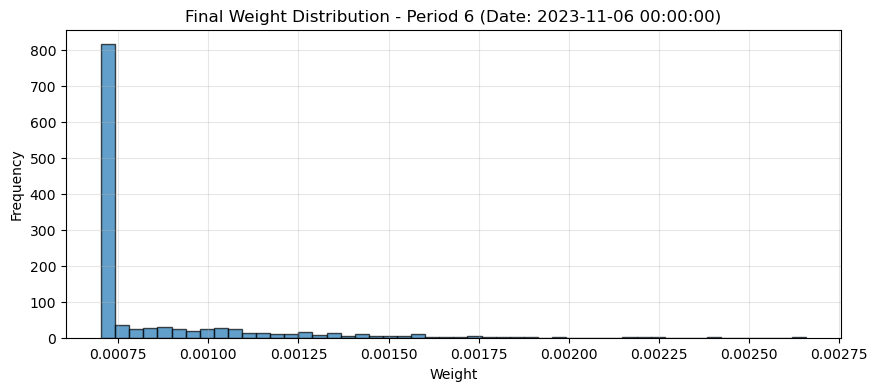

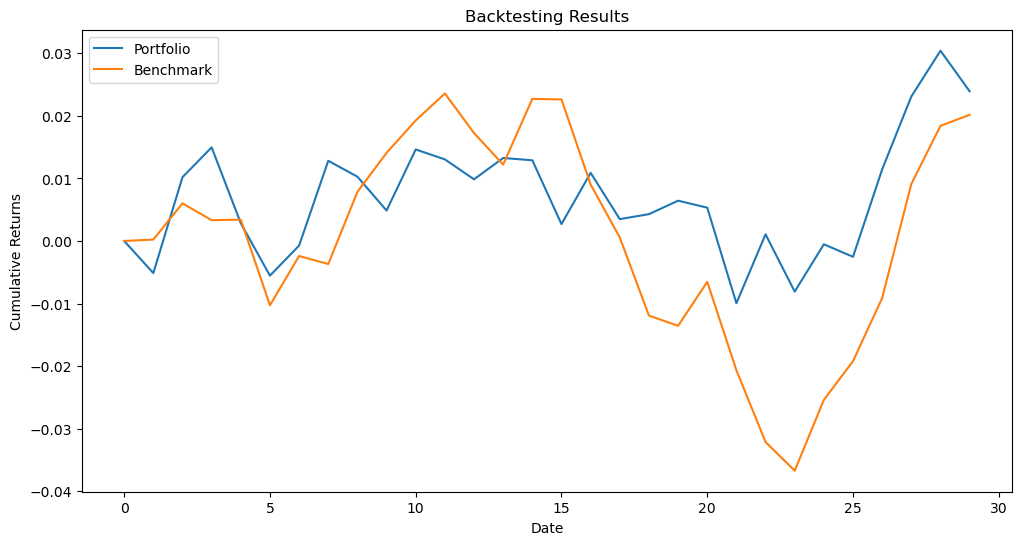

initial date: 2019-08-05 00:00:00


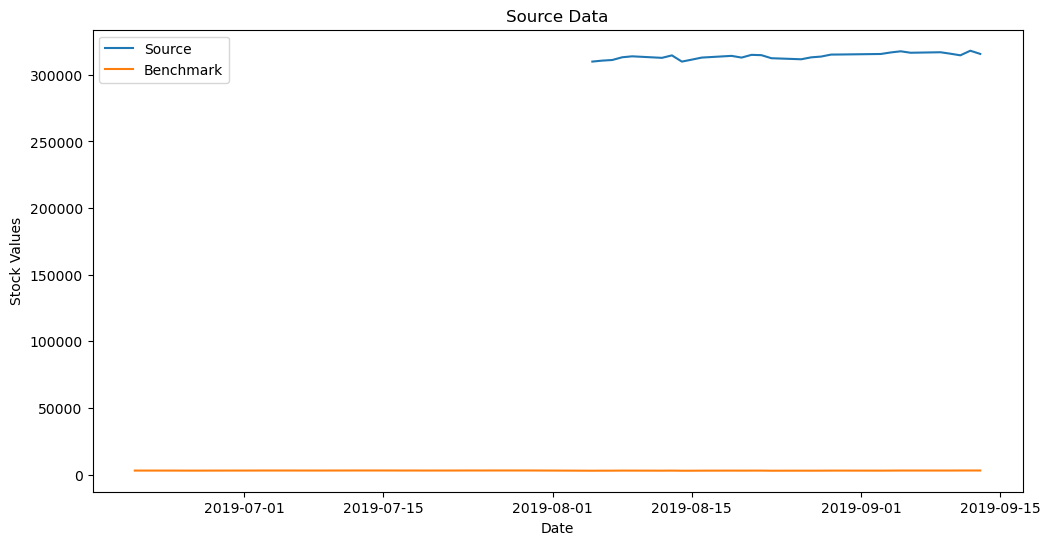

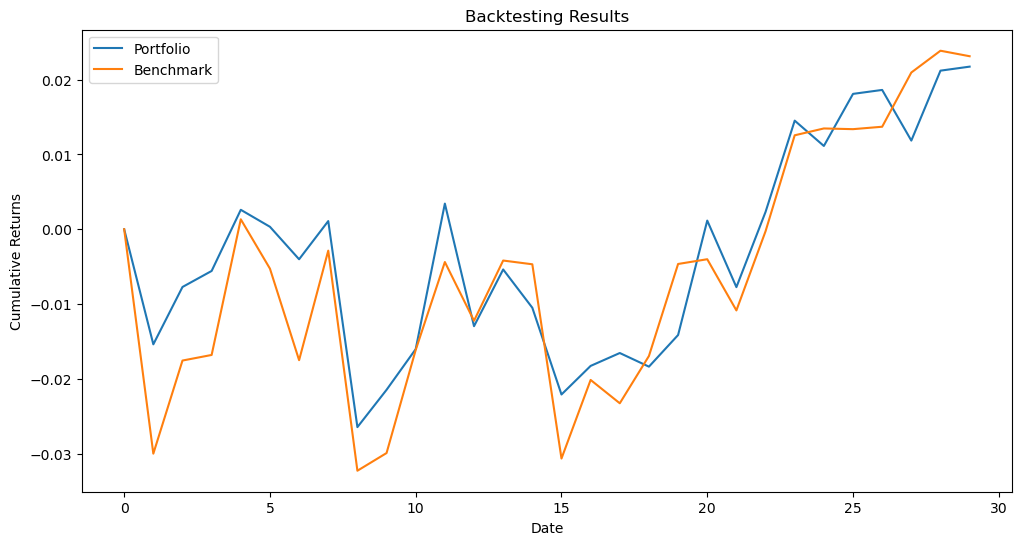

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_6.pkl

Period 7 Final Weights - Weight Statistics:
  Min weight:     0.000701
  Max weight:     0.002544
  Average weight: 0.000833
  Non-zero count: 1200/1200


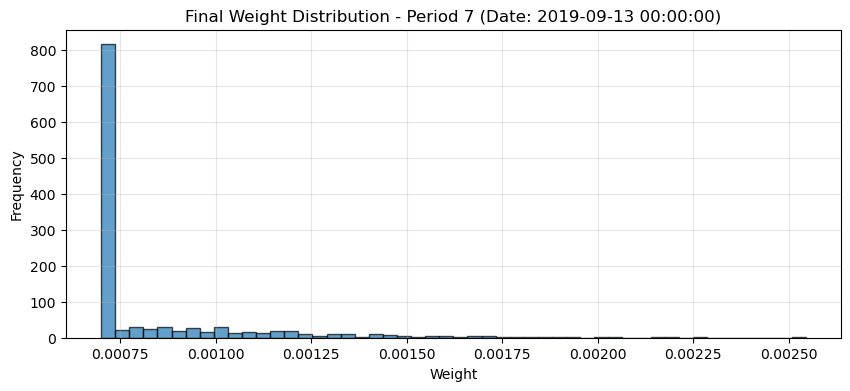

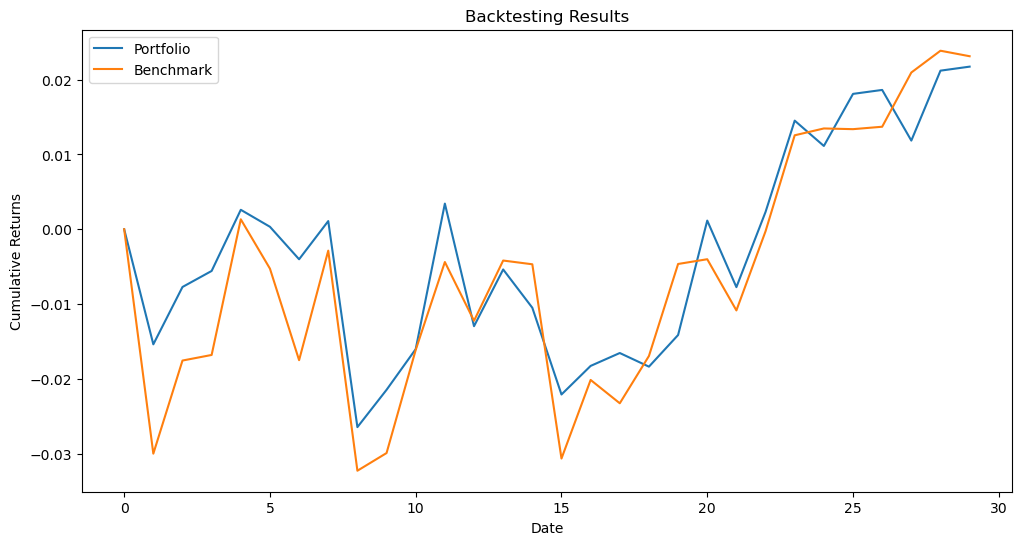

initial date: 2014-01-23 00:00:00


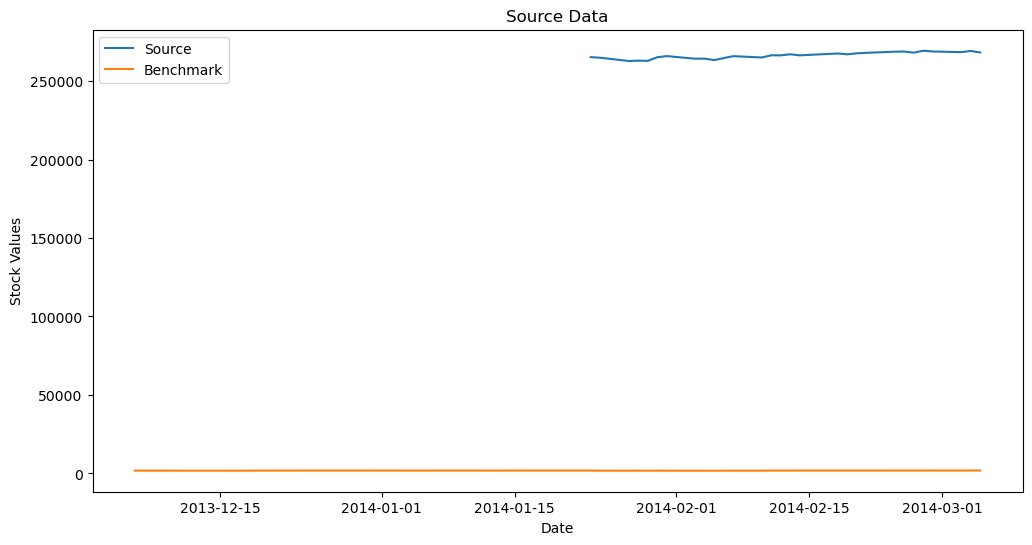

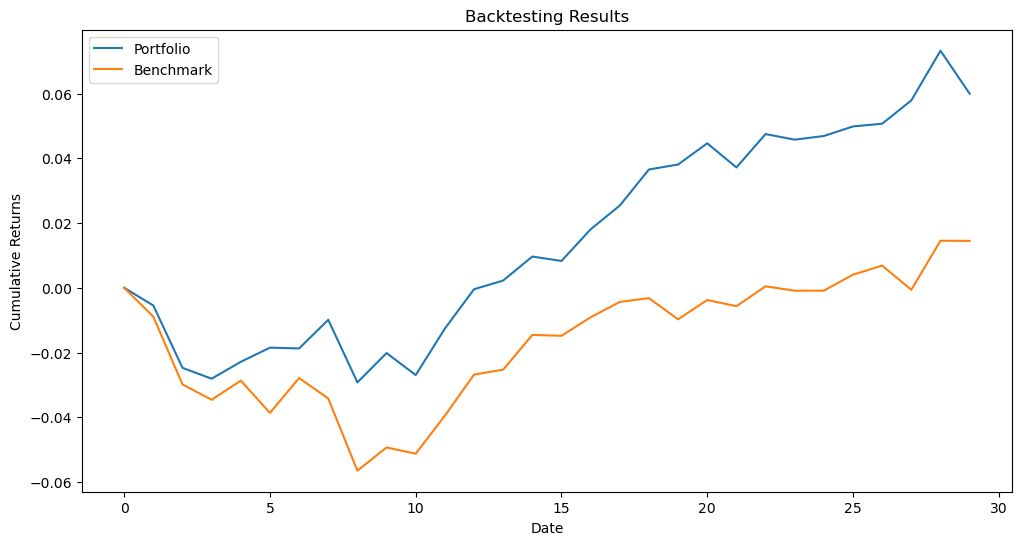

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_7.pkl

Period 8 Final Weights - Weight Statistics:
  Min weight:     0.000697
  Max weight:     0.002173
  Average weight: 0.000833
  Non-zero count: 1200/1200


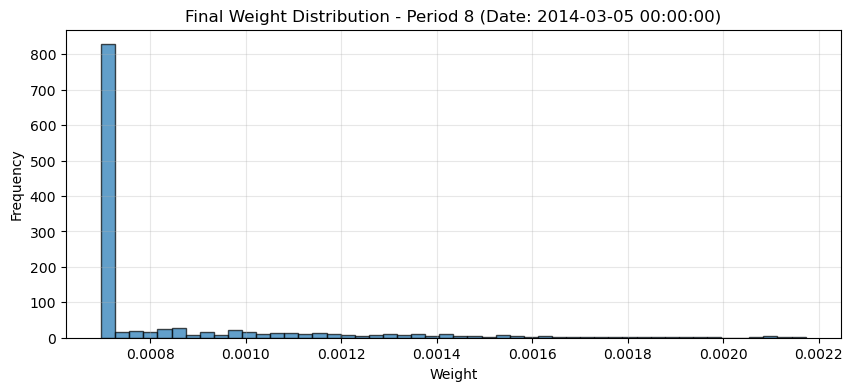

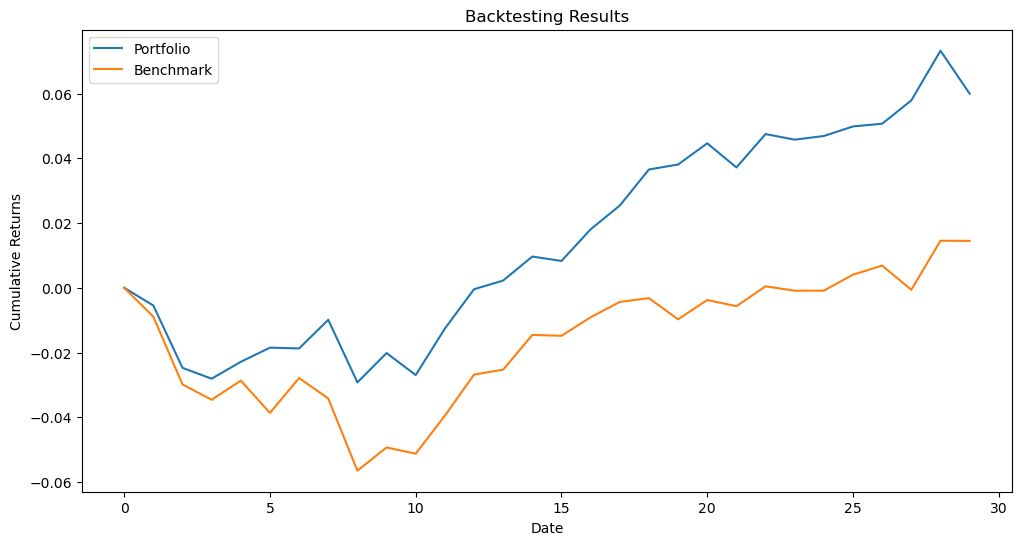

initial date: 2016-06-01 00:00:00


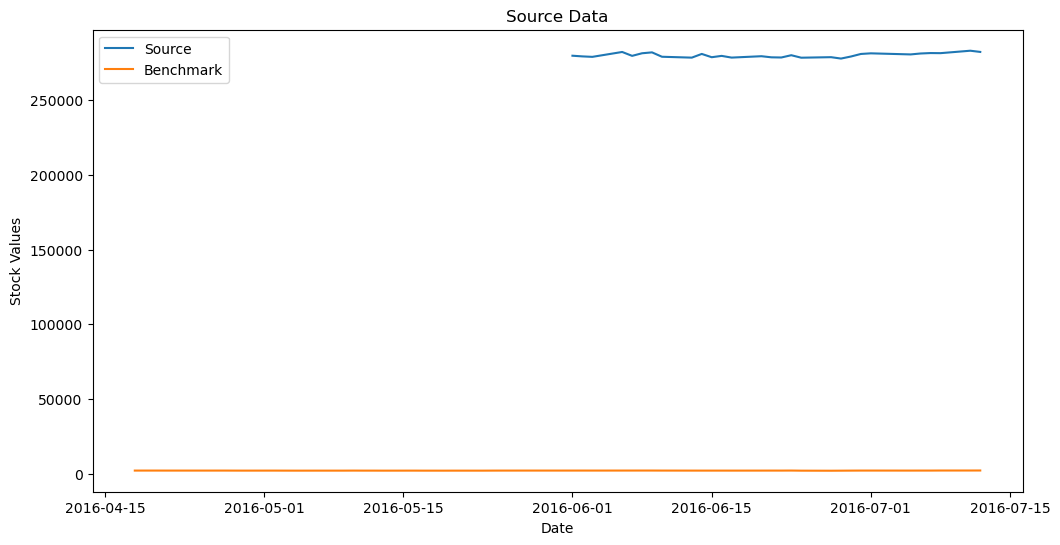

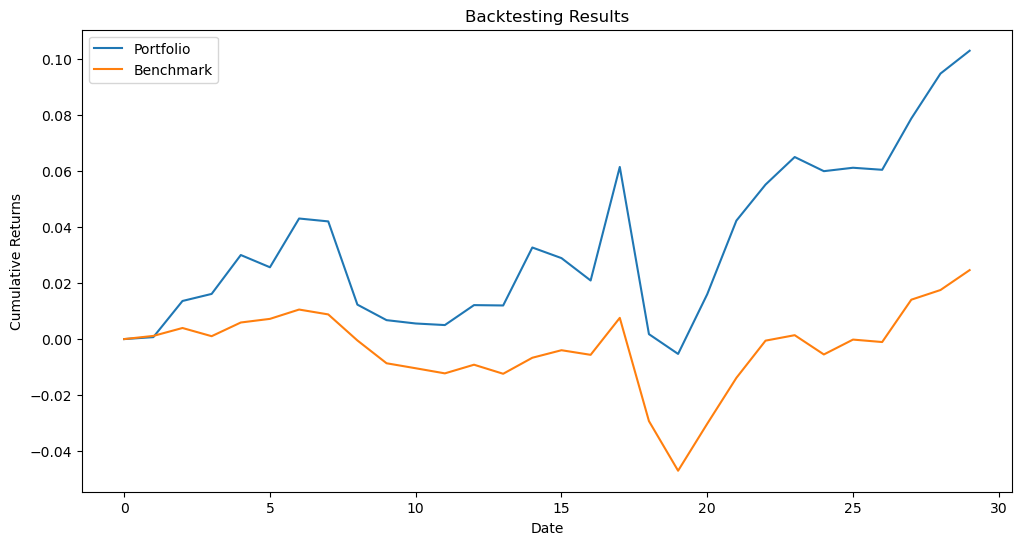

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_8.pkl

Period 9 Final Weights - Weight Statistics:
  Min weight:     0.000704
  Max weight:     0.002397
  Average weight: 0.000833
  Non-zero count: 1200/1200


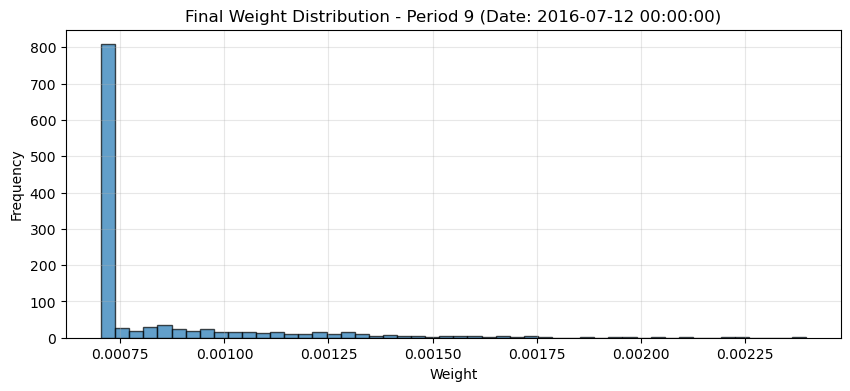

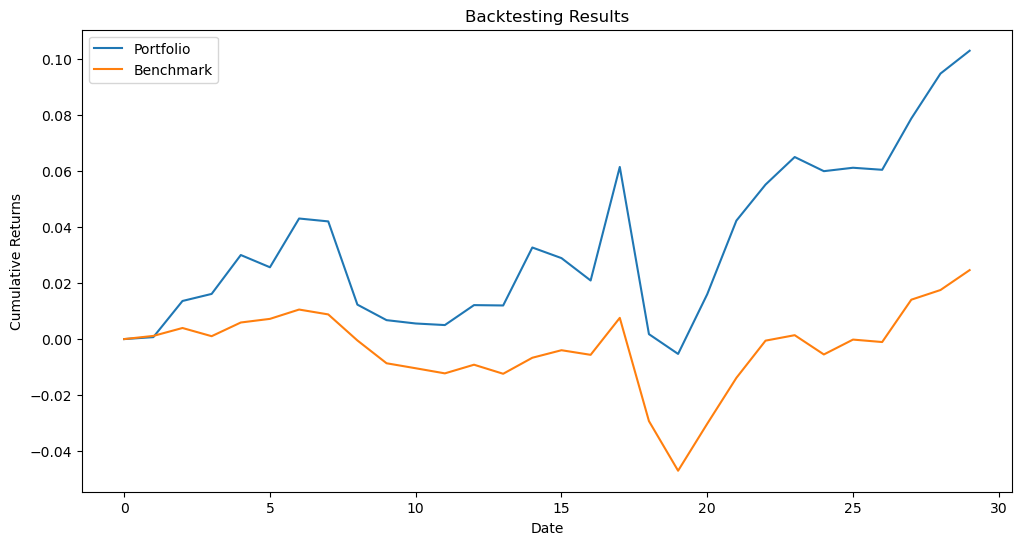

initial date: 2021-12-30 00:00:00


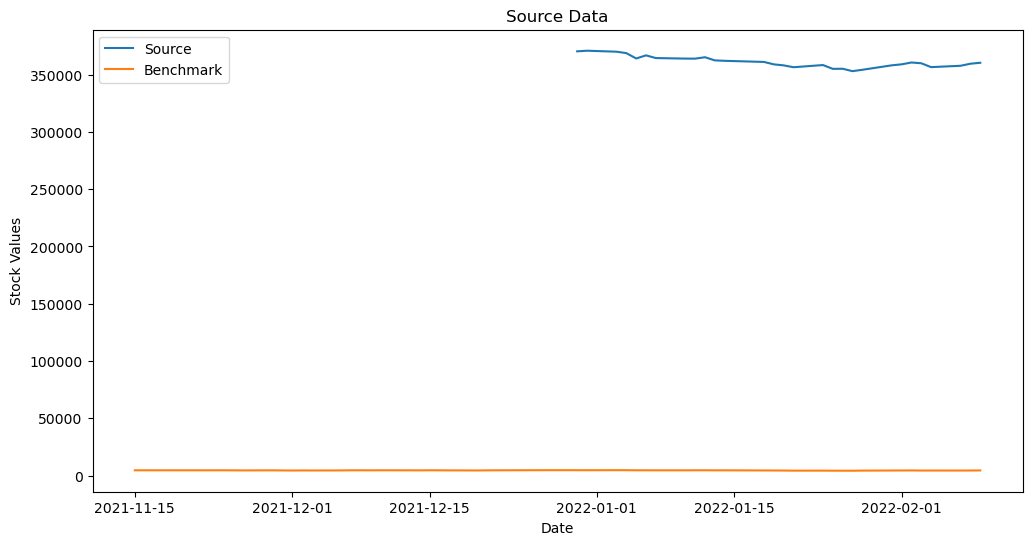

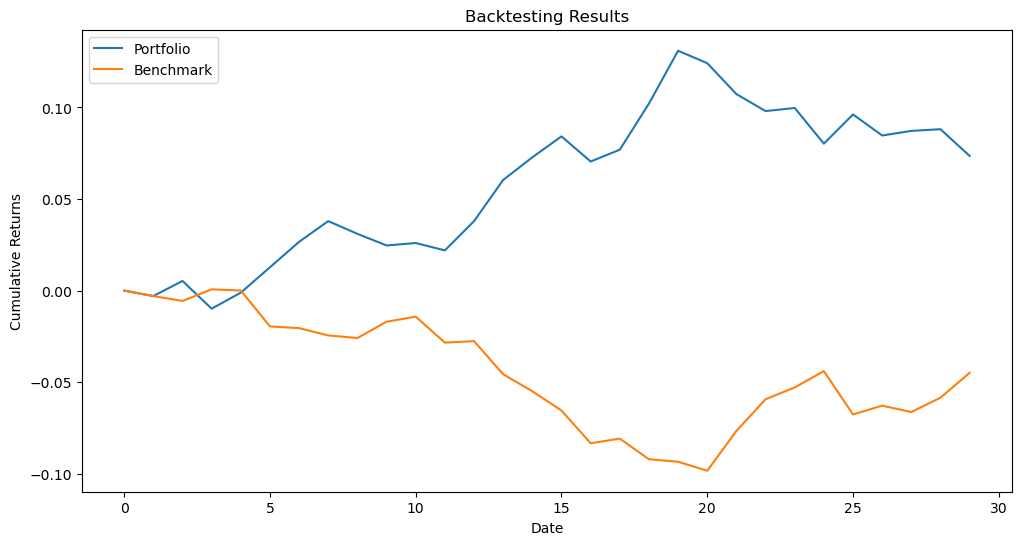

Dictionary pickled and saved to ../../results/qubo/results_synth_ga_9.pkl

Period 10 Final Weights - Weight Statistics:
  Min weight:     0.000701
  Max weight:     0.002822
  Average weight: 0.000833
  Non-zero count: 1200/1200


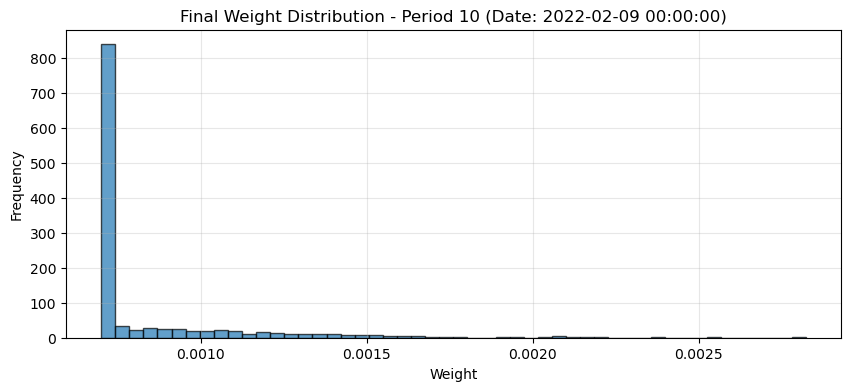

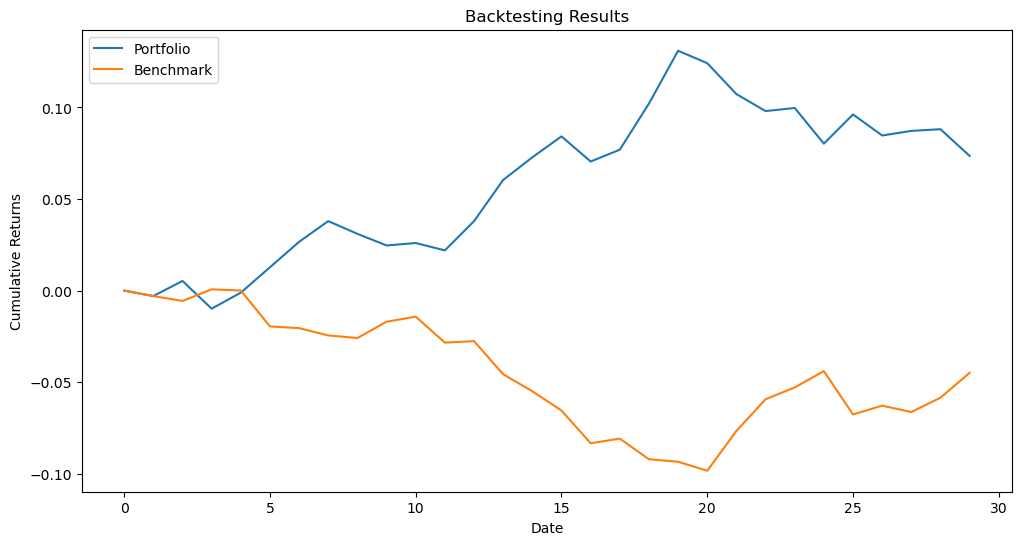

In [39]:
results_path_ga_synth = '../../results/qubo/results_synth_ga_{}.pkl'
_ = run_experiment(results_path_ga_synth, df_synth, benchmark, opt_fun_ga, parameters)

#### Scipy SLSQP Synth

initial date: 2014-01-13 00:00:00


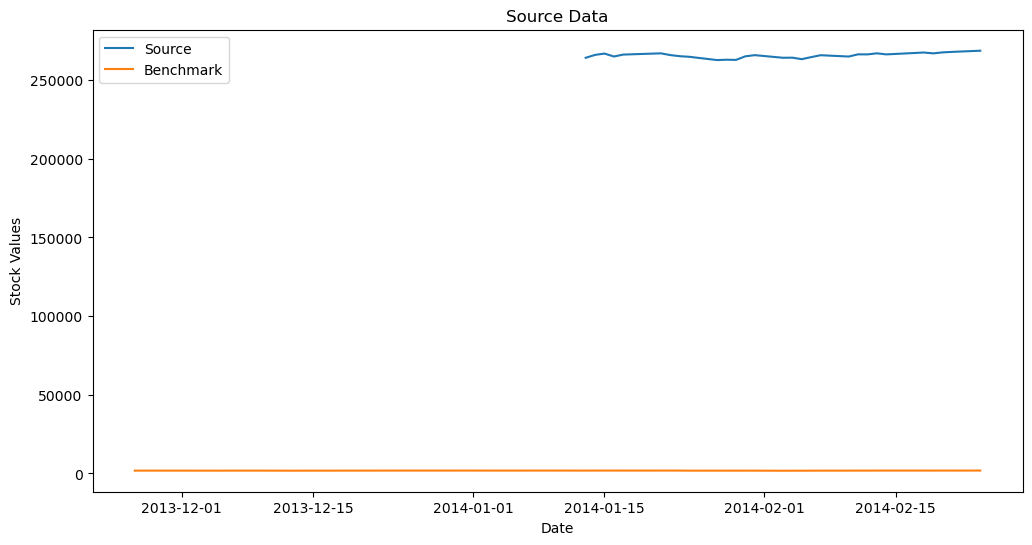

SciPy optimization failed: Inequality constraints incompatible
SciPy optimization failed: Inequality constraints incompatible
SciPy optimization failed: Inequality constraints incompatible
SciPy optimization failed: Positive directional derivative for linesearch


KeyboardInterrupt: 

In [ ]:
# results_path_bf_synth = '../../results/qubo/results_synth_bf_{}.pkl'
# _ = run_experiment(results_path_bf_synth, df_synth, benchmark, opt_fun_bf, parameters)

#### Synthetic Dataset Method Comparison

In [ ]:
# Comprehensive comparison of ALL optimization methods for Synthetic Dataset
synth_dataset_solvers = [
    {'path_template': '../../results/qubo/results_synth_ew_{}.pkl', 'name': 'Equal Weights'},
    {'path_template': '../../results/qubo/results_synth_ga_{}.pkl', 'name': 'Genetic Algorithm'},
    {'path_template': '../../results/qubo/results_synth_bf_{}.pkl', 'name': 'Scipy SLSQP'},
]

n_periods = parameters['n_periods']
multi_comparison(synth_dataset_solvers, n_periods, "QUBO Optimization Methods (Synthetic Dataset)")

# Generate comprehensive performance summary
print("\n" + "="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY - QUBO Methods (Synthetic Dataset)")
print("="*100)
summary_df_synth = performance_summary(synth_dataset_solvers, n_periods)
if not summary_df_synth.empty:
    # Sort by average return for better readability
    summary_df_synth_sorted = summary_df_synth.sort_values('Avg_Return', ascending=False)
    display(summary_df_synth_sorted)
    
    # Performance analysis
    print("\nPerformance Analysis:")
    print("-" * 50)
    print(f"Methods compared: {len(summary_df_synth)}")
    print(f"Best performer: {summary_df_synth_sorted.iloc[0]['Solver']} (avg return: {summary_df_synth_sorted.iloc[0]['Avg_Return']:.4f})")
    print(f"Fastest method: {summary_df_synth.loc[summary_df_synth['Avg_Time'].idxmin(), 'Solver']} ({summary_df_synth['Avg_Time'].min():.2f}s)")
    print(f"Most reliable: {summary_df_synth.loc[summary_df_synth['Success_Rate'].idxmax(), 'Solver']} ({summary_df_synth['Success_Rate'].max():.1f}%)")
else:
    print("No summary data available")